# Notebook 15 — SEI-only Capacity RPT Extension and Metric Registry v0.1

## Goal

This notebook extends the SEI-only multi-checkpoint fingerprint framework by adding a broader aging diagnostic metric registry.

The goal is to move beyond the initial Ri / tau1 / tau2 audit and include additional externally observable diagnostic layers.

## Scientific context

Notebook 14 showed that SEI-only aging under the current proof-of-concept protocol produces:

- strong degradation-state drift,
- weak but monotonic Ri drift,
- weak and non-dominant tau1 / tau2 drift.

The dominant SEI-only signature was classified as:

`capacity / LLI degradation-state dominant`

with a secondary:

`weak Ri-sensitive component`

Notebook 15 tests whether this interpretation can be strengthened by adding external capacity and richer voltage-response metrics.

## Metric Registry v0.1

This notebook introduces the following metric layers:

### 1. Degradation-state layer

- SEI thickness
- loss of lithium inventory
- total lithium lost
- capacity lost to side reactions
- SEI interfacial current

### 2. External capacity RPT layer

- discharge capacity
- capacity fade
- capacity retention

### 3. Multi-window resistance layer

- Ri_0.1s
- Ri_1s
- Ri_10s
- Ri_recovery_0.1s
- Ri_recovery_1s

### 4. Fitted relaxation layer

- tau1_60s
- tau1_300s
- tau2_60s
- tau2_300s

### 5. Non-parametric relaxation layer

- tau_FG_eff
- t95
- t99
- tau_tail
- recovery amplitude
- normalized recovery area

### 6. Voltage-curve / pseudo-OCV feasibility layer

- U00_after_fixed_rest
- voltage recovery amplitude after fixed endpoint
- feasibility flag for OCV / ICA / DVA extraction

### 7. Thermal layer

Thermal indicators are registered but deferred.

They should only be interpreted after a non-isothermal thermal model branch is enabled.

## Workflow

1. Import packages and audit paths.
2. Define SEI-only model configuration.
3. Define checkpoint schedule.
4. Define Metric Registry v0.1.
5. Define capacity RPT protocol.
6. Define HPPC/RPT protocol.
7. Define extraction functions:
   - degradation-state variables,
   - capacity RPT,
   - multi-window Ri,
   - fitted tau1/tau2,
   - non-parametric relaxation descriptors.
8. Run SEI-only aging checkpoints.
9. At each checkpoint, branch into:
   - capacity RPT,
   - HPPC/RPT.
10. Build unified metric table.
11. Classify the SEI-only fingerprint using the expanded metric registry.

## Interpretation boundary

This notebook does not establish a validated SEI aging law or real-cell SOH trajectory.

The current protocol remains a proof-of-concept simulation protocol.

The capacity RPT and HPPC/RPT branches are diagnostic only. They must not be used as the starting state for subsequent aging.

Voltage-curve / pseudo-OCV metrics are feasibility-level indicators in this notebook, not strict OCV-SOC measurements.

Thermal metrics are deferred until a non-isothermal model branch is activated.

In [1]:
# Cell 1 — Imports and path audit（导入库并确认项目路径）

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

from scipy.optimize import curve_fit

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
# Cell 2 — SEI-only model configuration（SEI-only 模型配置）

PARAMETER_SET = "OKane2022"
SEI_OPTION = "solvent-diffusion limited"

SEI_ONLY_OPTIONS = {
    "SEI": SEI_OPTION,
    "lithium plating": "none",
    "loss of active material": "none",
    "particle mechanics": "none",
    "SEI porosity change": "false",
}

param = pybamm.ParameterValues(PARAMETER_SET)
model = pybamm.lithium_ion.DFN(SEI_ONLY_OPTIONS)

print("Parameter set:", PARAMETER_SET)
print("SEI option:", SEI_OPTION)
print("Model options:", SEI_ONLY_OPTIONS)

Parameter set: OKane2022
SEI option: solvent-diffusion limited
Model options: {'SEI': ('solvent-diffusion limited', 'none'), 'lithium plating': 'none', 'loss of active material': 'none', 'particle mechanics': 'none', 'SEI porosity change': 'false'}


In [3]:
# Cell 3 — Checkpoint and protocol configuration（checkpoint 与协议配置）

CHECKPOINT_CYCLES = [0, 3, 10, 20]

AGING_OUTPUT_PERIOD = "120 seconds"
CAPACITY_RPT_OUTPUT_PERIOD = "60 seconds"
HPPC_RPT_OUTPUT_PERIOD = "0.1 seconds"

AGING_CYCLE_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 10 minutes",
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

CAPACITY_RPT_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 10 minutes",
]

HPPC_RPT_STEPS = [
    "Discharge at C/3 for 1.5 hours",
    "Rest for 60 seconds",
    "Discharge at 1C for 10 seconds",
    "Rest for 600 seconds",
]

RPT_CONDITIONING_STRATEGY = "time_based_approx_50soc"

print("Checkpoints:", CHECKPOINT_CYCLES)
print("Aging output period:", AGING_OUTPUT_PERIOD)
print("Capacity RPT output period:", CAPACITY_RPT_OUTPUT_PERIOD)
print("HPPC RPT output period:", HPPC_RPT_OUTPUT_PERIOD)

print("\nCapacity RPT steps:")
for i, step in enumerate(CAPACITY_RPT_STEPS, start=1):
    print(f"{i}. {step}")

print("\nHPPC RPT steps:")
for i, step in enumerate(HPPC_RPT_STEPS, start=1):
    print(f"{i}. {step}")

Checkpoints: [0, 3, 10, 20]
Aging output period: 120 seconds
Capacity RPT output period: 60 seconds
HPPC RPT output period: 0.1 seconds

Capacity RPT steps:
1. Discharge at C/3 until 2.5 V
2. Rest for 10 minutes

HPPC RPT steps:
1. Discharge at C/3 for 1.5 hours
2. Rest for 60 seconds
3. Discharge at 1C for 10 seconds
4. Rest for 600 seconds


In [4]:
# Cell 4 — Metric Registry v0.1（固定后续 aging fingerprint 审计指标体系）

metric_registry_rows = [
    {
        "layer": "degradation_state",
        "metric": "sei_thickness_m",
        "status": "active",
        "source": "PyBaMM internal variable",
        "interpretation": "SEI film growth",
    },
    {
        "layer": "degradation_state",
        "metric": "loss_lithium_inventory_pct",
        "status": "active",
        "source": "PyBaMM internal variable",
        "interpretation": "loss of cyclable lithium / LLI",
    },
    {
        "layer": "degradation_state",
        "metric": "total_lithium_lost_mol",
        "status": "active",
        "source": "PyBaMM internal variable",
        "interpretation": "absolute lithium loss",
    },
    {
        "layer": "degradation_state",
        "metric": "capacity_lost_side_reactions_Ah",
        "status": "active",
        "source": "PyBaMM internal variable",
        "interpretation": "side-reaction capacity loss",
    },
    {
        "layer": "capacity_rpt",
        "metric": "rpt_discharge_capacity_Ah",
        "status": "active",
        "source": "capacity RPT branch",
        "interpretation": "externally observable discharge capacity",
    },
    {
        "layer": "capacity_rpt",
        "metric": "capacity_retention_pct",
        "status": "active",
        "source": "capacity RPT branch",
        "interpretation": "capacity retention relative to 0-cycle RPT",
    },
    {
        "layer": "multi_window_Ri",
        "metric": "Ri_0p1s_mohm",
        "status": "active",
        "source": "HPPC pulse",
        "interpretation": "early pulse resistance",
    },
    {
        "layer": "multi_window_Ri",
        "metric": "Ri_1s_mohm",
        "status": "active",
        "source": "HPPC pulse",
        "interpretation": "1-second pulse resistance",
    },
    {
        "layer": "multi_window_Ri",
        "metric": "Ri_10s_mohm",
        "status": "active",
        "source": "HPPC pulse",
        "interpretation": "near-end pulse resistance",
    },
    {
        "layer": "multi_window_Ri",
        "metric": "Ri_recovery_0p1s_mohm",
        "status": "active",
        "source": "HPPC recovery",
        "interpretation": "early recovery resistance",
    },
    {
        "layer": "multi_window_Ri",
        "metric": "Ri_recovery_1s_mohm",
        "status": "active",
        "source": "HPPC recovery",
        "interpretation": "1-second recovery resistance",
    },
    {
        "layer": "fitted_relaxation",
        "metric": "tau1_60s / tau1_300s / tau2_60s / tau2_300s",
        "status": "active",
        "source": "biexponential fit",
        "interpretation": "fit-window-dependent relaxation descriptors",
    },
    {
        "layer": "nonparametric_relaxation",
        "metric": "tau_FG_eff",
        "status": "active",
        "source": "relaxation recovery curve",
        "interpretation": "63.2% recovery time",
    },
    {
        "layer": "nonparametric_relaxation",
        "metric": "t95 / t99",
        "status": "active",
        "source": "relaxation recovery curve",
        "interpretation": "time to 95% / 99% recovery",
    },
    {
        "layer": "nonparametric_relaxation",
        "metric": "tau_tail",
        "status": "active",
        "source": "late relaxation semilog slope",
        "interpretation": "late-tail effective time constant",
    },
    {
        "layer": "nonparametric_relaxation",
        "metric": "recovery_amplitude / recovery_area",
        "status": "active",
        "source": "relaxation recovery curve",
        "interpretation": "non-parametric recovery morphology",
    },
    {
        "layer": "voltage_recovery_pseudo_ocv",
        "metric": "U00_after_fixed_rest",
        "status": "feasibility",
        "source": "fixed endpoint + rest protocol",
        "interpretation": "pseudo-OCV / voltage recovery fingerprint, not strict OCV",
    },
    {
        "layer": "voltage_curve_ICA_DVA",
        "metric": "OCV shift / ICA / DVA",
        "status": "deferred",
        "source": "requires low-rate or quasi-equilibrium voltage curve",
        "interpretation": "requires dedicated protocol",
    },
    {
        "layer": "thermal",
        "metric": "heat generation / temperature rise",
        "status": "deferred_until_non_isothermal_branch",
        "source": "thermal model",
        "interpretation": "not interpretable under current isothermal configuration",
    },
]

metric_registry = pd.DataFrame(metric_registry_rows)

out_csv = DATA / "metric_registry_v0_1.csv"
metric_registry.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(metric_registry)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/metric_registry_v0_1.csv


,layer,metric,status,source,interpretation
0,degradation_state,sei_thickness_m,active,PyBaMM internal variable,SEI film growth
1,degradation_state,loss_lithium_inventory_pct,active,PyBaMM internal variable,loss of cyclable lithium / LLI
2,degradation_state,total_lithium_lost_mol,active,PyBaMM internal variable,absolute lithium loss
3,degradation_state,capacity_lost_side_reactions_Ah,active,PyBaMM internal variable,side-reaction capacity loss
4,capacity_rpt,rpt_discharge_capacity_Ah,active,capacity RPT branch,externally observable discharge capacity
5,capacity_rpt,capacity_retention_pct,active,capacity RPT branch,capacity retention relative to 0-cycle RPT
6,multi_window_Ri,Ri_0p1s_mohm,active,HPPC pulse,early pulse resistance
7,multi_window_Ri,Ri_1s_mohm,active,HPPC pulse,1-second pulse resistance
8,multi_window_Ri,Ri_10s_mohm,active,HPPC pulse,near-end pulse resistance
9,multi_window_Ri,Ri_recovery_0p1s_mohm,active,HPPC recovery,early recovery resistance


In [5]:
# Cell 5 — Degradation variable selection（选择 SEI / LLI / capacity 老化变量）

degradation_variable_candidates = {
    "sei_thickness_m": [
        "X-averaged negative SEI thickness [m]",
        "X-averaged SEI thickness [m]",
        "Negative SEI thickness [m]",
    ],
    "loss_lithium_inventory_pct": [
        "Loss of lithium inventory [%]",
    ],
    "total_lithium_lost_mol": [
        "Total lithium lost [mol]",
        "Total lithium lost to side reactions [mol]",
    ],
    "capacity_lost_side_reactions_Ah": [
        "Total capacity lost to side reactions [A.h]",
        "Loss of capacity to negative SEI [A.h]",
        "Loss of capacity to SEI [A.h]",
    ],
    "sei_interfacial_current_A_m2": [
        "X-averaged negative electrode SEI interfacial current density [A.m-2]",
        "X-averaged SEI interfacial current density [A.m-2]",
    ],
}


def first_available_solution_variable(solution, candidates):
    for name in candidates:
        try:
            _ = solution[name].entries
            return name
        except Exception:
            pass
    return None


def get_solution_var_final(solution, candidates):
    selected = first_available_solution_variable(solution, candidates)

    if selected is None:
        return None, np.nan

    values = np.asarray(solution[selected].entries)

    if values.ndim == 1:
        return selected, float(values[-1])

    return selected, float(np.mean(values[..., -1]))


selected_model_variables = {}

for short_name, candidates in degradation_variable_candidates.items():
    selected = None
    for name in candidates:
        if name in model.variables:
            selected = name
            break
    selected_model_variables[short_name] = selected

selected_model_variables

{'sei_thickness_m': 'X-averaged negative SEI thickness [m]',
 'loss_lithium_inventory_pct': 'Loss of lithium inventory [%]',
 'total_lithium_lost_mol': 'Total lithium lost [mol]',
 'capacity_lost_side_reactions_Ah': 'Total capacity lost to side reactions [A.h]',
 'sei_interfacial_current_A_m2': 'X-averaged negative electrode SEI interfacial current density [A.m-2]'}

In [6]:
# Cell 6 — Aging / capacity RPT / HPPC RPT branch helpers（老化、容量RPT、HPPC-RPT分支函数）

def build_aging_experiment(n_cycles):
    if n_cycles <= 0:
        raise ValueError("n_cycles must be positive for an aging block.")

    return pybamm.Experiment(
        AGING_CYCLE_STEPS * n_cycles,
        period=AGING_OUTPUT_PERIOD,
    )


def build_capacity_rpt_experiment():
    return pybamm.Experiment(
        CAPACITY_RPT_STEPS,
        period=CAPACITY_RPT_OUTPUT_PERIOD,
    )


def build_hppc_rpt_experiment():
    return pybamm.Experiment(
        HPPC_RPT_STEPS,
        period=HPPC_RPT_OUTPUT_PERIOD,
    )


def run_aging_block(starting_solution, n_cycles, label):
    experiment = build_aging_experiment(n_cycles)

    sim = pybamm.Simulation(
        model,
        parameter_values=param,
        experiment=experiment,
    )

    if starting_solution is None:
        sim.set_initial_soc(1.0, direction="discharge")
        sol = sim.solve()
    else:
        sol = sim.solve(starting_solution=starting_solution)

    print(f"[OK] aging block solved: {label}")
    print("  cycles in block:", n_cycles)
    print("  final time [h]:", float(sol["Time [h]"].entries[-1]))

    return sol


def run_branch_experiment(starting_solution, experiment, output_label, initial_soc_if_none=1.0):
    sim = pybamm.Simulation(
        model,
        parameter_values=param,
        experiment=experiment,
    )

    if starting_solution is None:
        sim.set_initial_soc(initial_soc_if_none, direction="discharge")
        branch_start_s = 0.0
        sol = sim.solve()
    else:
        branch_start_s = float(starting_solution["Time [s]"].entries[-1])
        sol = sim.solve(starting_solution=starting_solution)

    df = pd.DataFrame(
        {
            "time_s": sol["Time [s]"].entries,
            "time_h": sol["Time [h]"].entries,
            "voltage_V": sol["Terminal voltage [V]"].entries,
            "current_A_pybamm": sol["Current [A]"].entries,
            "discharge_capacity_Ah": sol["Discharge capacity [A.h]"].entries,
            "throughput_capacity_Ah": sol["Throughput capacity [A.h]"].entries,
        }
    )

    df["current_A_exp"] = -df["current_A_pybamm"]

    segment = df[df["time_s"] >= branch_start_s].copy()
    segment["branch_time_s"] = segment["time_s"] - segment["time_s"].iloc[0]
    segment["branch_time_h"] = segment["branch_time_s"] / 3600

    print(f"[OK] branch solved: {output_label}")
    print("  segment duration [h]:", float(segment["branch_time_h"].iloc[-1]))

    return sol, segment


print("[OK] branch helpers defined")

[OK] branch helpers defined


In [13]:
# Cell 6b — Restore RPT CDEFG / tau extraction helpers（补回 RPT CDEFG / tau 提取函数）

def extract_rpt_cdefg_and_ri(df, pulse_threshold_factor=0.8):
    """
    Extract CDEFG / Ri from RPT dataframe.

    The RPT contains a long C/3 conditioning discharge before the HPPC pulse.
    Therefore, this function detects the high-current 1C pulse.
    """
    t = df["rpt_time_s"].values
    u = df["voltage_V"].values
    i = df["current_A_pybamm"].values

    threshold = pulse_threshold_factor * np.nanmax(np.abs(i))
    pulse_mask = np.abs(i) >= threshold
    pulse_indices = np.where(pulse_mask)[0]

    if len(pulse_indices) == 0:
        raise ValueError("No HPPC pulse detected.")

    pulse_start_idx = pulse_indices[0]
    pulse_end_idx = pulse_indices[-1]

    t_start = float(t[pulse_start_idx])
    t_end = float(t[pulse_end_idx])

    C_window = (t >= t_start - 1.0) & (t < t_start)
    D_window = (t >= t_start + 0.1) & (t <= t_start + 0.3)
    E_window = (t >= t_end - 0.3) & (t <= t_end)
    F_window = (t > t_end) & (t <= t_end + 0.3)
    G_window = (t >= t_end + 600 - 10) & (t <= t_end + 600)

    windows = {
        "C": C_window,
        "D": D_window,
        "E": E_window,
        "F": F_window,
        "G": G_window,
    }

    points = {}
    for label, mask in windows.items():
        if mask.sum() == 0:
            raise ValueError(f"{label} window has no data points.")

        points[label] = {
            "t_s": float(np.median(t[mask])),
            "U_V": float(np.median(u[mask])),
            "n_points": int(mask.sum()),
        }

    I_C = float(np.median(i[C_window]))
    I_D = float(np.median(i[D_window]))
    I_E = float(np.median(i[E_window]))
    I_F = float(np.median(i[F_window]))

    Ri_CD_mohm = abs((points["D"]["U_V"] - points["C"]["U_V"]) / (I_D - I_C)) * 1000
    Ri_EF_mohm = abs((points["F"]["U_V"] - points["E"]["U_V"]) / (I_F - I_E)) * 1000

    result = {
        "pulse_start_s": t_start,
        "pulse_end_s": t_end,
        "pulse_duration_s": t_end - t_start,
        "Ri_CD_mohm": Ri_CD_mohm,
        "Ri_EF_mohm": Ri_EF_mohm,
        "C_U_V": points["C"]["U_V"],
        "D_U_V": points["D"]["U_V"],
        "E_U_V": points["E"]["U_V"],
        "F_U_V": points["F"]["U_V"],
        "G_U_V": points["G"]["U_V"],
    }

    return result, points


def fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0, tail_start_s=550.0):
    fit_mask = (
        (relax["t_relax_s"] >= fit_t_min)
        & (relax["t_relax_s"] <= fit_t_max)
    )

    t_fit = relax.loc[fit_mask, "t_relax_s"].values
    u_fit = relax.loc[fit_mask, "voltage_V"].values

    if len(t_fit) < 20:
        raise ValueError("Not enough relaxation points for biexponential fit.")

    tail_mask = relax["t_relax_s"] >= tail_start_s
    Uinf = float(np.median(relax.loc[tail_mask, "voltage_V"]))

    def biexp(t, A1, tau1, A2, tau2):
        return Uinf - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

    A_total = Uinf - u_fit[0]
    p0 = [0.6 * A_total, 3.0, 0.4 * A_total, 30.0]
    bounds = ([0.0, 0.1, 0.0, 1.0], [1.0, 100.0, 1.0, 1000.0])

    popt, _ = curve_fit(
        biexp,
        t_fit,
        u_fit,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )

    A1, tau1, A2, tau2 = popt

    if tau1 > tau2:
        A1, A2 = A2, A1
        tau1, tau2 = tau2, tau1

    u_pred = biexp(t_fit, A1, tau1, A2, tau2)
    residual = u_fit - u_pred

    ss_res = np.sum(residual**2)
    ss_tot = np.sum((u_fit - np.mean(u_fit))**2)
    r2 = 1 - ss_res / ss_tot
    rmse_mV = np.sqrt(np.mean(residual**2)) * 1000

    return {
        "tau1_s": float(tau1),
        "tau2_s": float(tau2),
        "R2": float(r2),
        "RMSE_mV": float(rmse_mV),
        "fit_t_min_s": fit_t_min,
        "fit_t_max_s": fit_t_max,
        "n_fit_points": int(len(t_fit)),
    }


def extract_rpt_tau(df, cdefg_result):
    relax_mask = (
        (df["rpt_time_s"] > cdefg_result["pulse_end_s"])
        & (df["rpt_time_s"] <= cdefg_result["pulse_end_s"] + 600)
    )

    relax = df.loc[relax_mask].copy()
    relax["t_relax_s"] = relax["rpt_time_s"] - cdefg_result["pulse_end_s"]

    fit60 = fit_biexp_with_window(relax, fit_t_max=60.0)
    fit300 = fit_biexp_with_window(relax, fit_t_max=300.0)

    return fit60, fit300, relax


print("[OK] restored extract_rpt_cdefg_and_ri(), fit_biexp_with_window(), extract_rpt_tau()")

[OK] restored extract_rpt_cdefg_and_ri(), fit_biexp_with_window(), extract_rpt_tau()


In [14]:
# Cell 6c — Helper function check（确认缺失函数已恢复）

for name in [
    "extract_rpt_cdefg_and_ri",
    "fit_biexp_with_window",
    "extract_rpt_tau",
    "extract_multi_window_ri",
    "extract_nonparametric_relaxation_descriptors",
]:
    print(name, name in globals())

extract_rpt_cdefg_and_ri True
fit_biexp_with_window True
extract_rpt_tau True
extract_multi_window_ri True
extract_nonparametric_relaxation_descriptors True


In [7]:
# Cell 7 — Capacity RPT extraction（容量 RPT 提取函数）

def extract_capacity_rpt_metrics(capacity_segment, checkpoint_cycles):
    """
    Extract external discharge capacity from a capacity-RPT branch.

    Capacity RPT branch:
    - Discharge at C/3 until 2.5 V
    - Rest for 10 min

    The discharge capacity increment during the branch is treated as the external
    RPT discharge capacity.
    """
    q_start = float(capacity_segment["discharge_capacity_Ah"].iloc[0])
    q_end = float(capacity_segment["discharge_capacity_Ah"].max())

    rpt_capacity_Ah = q_end - q_start

    try:
        nominal_capacity_Ah = float(param["Nominal cell capacity [A.h]"])
    except Exception:
        nominal_capacity_Ah = np.nan

    return {
        "checkpoint_cycles": checkpoint_cycles,
        "rpt_discharge_capacity_Ah": rpt_capacity_Ah,
        "nominal_capacity_Ah": nominal_capacity_Ah,
        "rpt_capacity_fraction_of_nominal": (
            rpt_capacity_Ah / nominal_capacity_Ah
            if np.isfinite(nominal_capacity_Ah) and nominal_capacity_Ah > 0
            else np.nan
        ),
        "capacity_rpt_duration_h": float(capacity_segment["branch_time_h"].iloc[-1]),
        "capacity_rpt_voltage_start_V": float(capacity_segment["voltage_V"].iloc[0]),
        "capacity_rpt_voltage_end_V": float(capacity_segment["voltage_V"].iloc[-1]),
    }


print("[OK] capacity RPT extractor defined")

[OK] capacity RPT extractor defined


In [8]:
# Cell 8 — Multi-window Ri extraction（多时间窗 Ri 提取函数）

def median_voltage_current_near(df, time_col, target_t, half_window_s=0.05):
    """
    Return median voltage/current around target time.
    """
    mask = (
        (df[time_col] >= target_t - half_window_s)
        & (df[time_col] <= target_t + half_window_s)
    )

    if mask.sum() == 0:
        return np.nan, np.nan, 0

    U = float(np.median(df.loc[mask, "voltage_V"]))
    I = float(np.median(df.loc[mask, "current_A_pybamm"]))

    return U, I, int(mask.sum())


def detect_hppc_pulse(df, time_col="rpt_time_s", pulse_threshold_factor=0.8):
    """
    Detect high-current 1C pulse within HPPC-RPT branch.
    """
    i_abs = np.abs(df["current_A_pybamm"].values)
    threshold = pulse_threshold_factor * np.nanmax(i_abs)

    pulse_mask = i_abs >= threshold
    pulse_indices = np.where(pulse_mask)[0]

    if len(pulse_indices) == 0:
        raise ValueError("No HPPC pulse detected.")

    pulse_start_idx = pulse_indices[0]
    pulse_end_idx = pulse_indices[-1]

    t_start = float(df[time_col].iloc[pulse_start_idx])
    t_end = float(df[time_col].iloc[pulse_end_idx])

    return t_start, t_end, threshold


def extract_multi_window_ri(df, checkpoint_cycles):
    """
    Extract multi-window Ri metrics from HPPC-RPT branch.

    PyBaMM convention:
    +I = discharge
    -I = charge

    Resistance uses absolute ΔU / ΔI.
    """
    time_col = "rpt_time_s"

    t_start, t_end, threshold = detect_hppc_pulse(df, time_col=time_col)

    # Pre-pulse baseline: 1 s before pulse start
    U_C, I_C, n_C = median_voltage_current_near(
        df, time_col, t_start - 0.5, half_window_s=0.5
    )

    # Pulse-on windows
    pulse_targets = {
        "0p1s": t_start + 0.1,
        "1s": t_start + 1.0,
        "10s": t_end - 0.1,
    }

    out = {
        "checkpoint_cycles": checkpoint_cycles,
        "pulse_start_s": t_start,
        "pulse_end_s": t_end,
        "pulse_duration_s": t_end - t_start,
        "pulse_threshold_A": threshold,
        "U_C_V": U_C,
        "I_C_A_pybamm": I_C,
        "n_C": n_C,
    }

    for label, target_t in pulse_targets.items():
        U, I, n = median_voltage_current_near(
            df, time_col, target_t, half_window_s=0.05
        )

        ri = abs((U - U_C) / (I - I_C)) * 1000

        out[f"U_pulse_{label}_V"] = U
        out[f"I_pulse_{label}_A_pybamm"] = I
        out[f"Ri_{label}_mohm"] = ri
        out[f"n_pulse_{label}"] = n

    # End-of-pulse reference for recovery resistance
    U_E, I_E, n_E = median_voltage_current_near(
        df, time_col, t_end - 0.1, half_window_s=0.05
    )

    out["U_E_V"] = U_E
    out["I_E_A_pybamm"] = I_E
    out["n_E"] = n_E

    recovery_targets = {
        "0p1s": t_end + 0.1,
        "1s": t_end + 1.0,
    }

    for label, target_t in recovery_targets.items():
        U, I, n = median_voltage_current_near(
            df, time_col, target_t, half_window_s=0.05
        )

        ri_rec = abs((U - U_E) / (I - I_E)) * 1000

        out[f"U_recovery_{label}_V"] = U
        out[f"I_recovery_{label}_A_pybamm"] = I
        out[f"Ri_recovery_{label}_mohm"] = ri_rec
        out[f"n_recovery_{label}"] = n

    return out


print("[OK] multi-window Ri extractor defined")

[OK] multi-window Ri extractor defined


In [9]:
# Cell 9 — Non-parametric relaxation descriptors（非参数 relaxation 描述符）

def extract_nonparametric_relaxation_descriptors(df, cdefg_result):
    """
    Extract non-parametric relaxation descriptors after HPPC pulse.

    Definitions:
    - U0: first recovery voltage after pulse-off
    - Uinf: median voltage over final 50 s of relaxation
    - recovery_fraction = (U(t) - U0) / (Uinf - U0)
    - tau_FG_eff: first time reaching 63.2% recovery
    - t95/t99: first time reaching 95% / 99% recovery
    - tau_tail: effective time constant from late semilog slope
    - recovery_area: integral of normalized remaining polarization
    """
    t_end = cdefg_result["pulse_end_s"]

    relax = df[
        (df["rpt_time_s"] > t_end)
        & (df["rpt_time_s"] <= t_end + 600)
    ].copy()

    relax["t_relax_s"] = relax["rpt_time_s"] - t_end

    if len(relax) < 20:
        raise ValueError("Not enough relaxation data.")

    U0 = float(relax["voltage_V"].iloc[0])
    Uinf = float(np.median(relax.loc[relax["t_relax_s"] >= 550, "voltage_V"]))

    amplitude = Uinf - U0

    if abs(amplitude) < 1e-12:
        relax["recovery_fraction"] = np.nan
        relax["remaining_fraction"] = np.nan
    else:
        relax["recovery_fraction"] = (relax["voltage_V"] - U0) / amplitude
        relax["remaining_fraction"] = (Uinf - relax["voltage_V"]) / amplitude

    def first_time_at_fraction(frac):
        valid = relax[
            np.isfinite(relax["recovery_fraction"])
            & (relax["recovery_fraction"] >= frac)
        ]
        if len(valid) == 0:
            return np.nan
        return float(valid["t_relax_s"].iloc[0])

    tau_FG_eff = first_time_at_fraction(1 - np.exp(-1))  # 63.2%
    t95 = first_time_at_fraction(0.95)
    t99 = first_time_at_fraction(0.99)

    # Recovery area: integral of remaining fraction over first 600 s
    valid_area = relax[
        np.isfinite(relax["remaining_fraction"])
        & (relax["remaining_fraction"] >= 0)
    ].copy()

    if len(valid_area) >= 2:
        recovery_area_s = float(
            np.trapz(
                valid_area["remaining_fraction"].values,
                valid_area["t_relax_s"].values,
            )
        )
    else:
        recovery_area_s = np.nan

    # Tail tau from semilog remaining fraction between 300 and 550 s
    tail = relax[
        (relax["t_relax_s"] >= 300)
        & (relax["t_relax_s"] <= 550)
        & np.isfinite(relax["remaining_fraction"])
        & (relax["remaining_fraction"] > 1e-5)
        & (relax["remaining_fraction"] < 1.0)
    ].copy()

    if len(tail) >= 10:
        x = tail["t_relax_s"].values
        y = np.log(tail["remaining_fraction"].values)

        slope, intercept = np.polyfit(x, y, 1)

        if slope < 0:
            tau_tail = float(-1 / slope)
        else:
            tau_tail = np.nan
    else:
        tau_tail = np.nan

    return {
        "relax_U0_V": U0,
        "relax_Uinf_V": Uinf,
        "recovery_amplitude_V": amplitude,
        "tau_FG_eff_s": tau_FG_eff,
        "t95_s": t95,
        "t99_s": t99,
        "tau_tail_s": tau_tail,
        "recovery_area_s": recovery_area_s,
    }, relax


print("[OK] non-parametric relaxation extractor defined")

[OK] non-parametric relaxation extractor defined


In [16]:
# Cell 9b — Patch non-parametric relaxation extractor for NumPy compatibility
# 功能：修复 np.trapz 不可用的问题，改用兼容的 trapezoid 积分实现

def trapezoid_integral(y, x):
    """
    Robust trapezoidal integration.

    Uses np.trapezoid if available. Falls back to manual implementation.
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)

    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(y, x))

    # Manual fallback
    if len(y) < 2:
        return np.nan

    dx = np.diff(x)
    y_mid = 0.5 * (y[:-1] + y[1:])
    return float(np.sum(dx * y_mid))


def extract_nonparametric_relaxation_descriptors(df, cdefg_result):
    """
    Extract non-parametric relaxation descriptors after HPPC pulse.

    Definitions:
    - U0: first recovery voltage after pulse-off
    - Uinf: median voltage over final 50 s of relaxation
    - recovery_fraction = (U(t) - U0) / (Uinf - U0)
    - tau_FG_eff: first time reaching 63.2% recovery
    - t95/t99: first time reaching 95% / 99% recovery
    - tau_tail: effective time constant from late semilog slope
    - recovery_area: integral of normalized remaining polarization
    """
    t_end = cdefg_result["pulse_end_s"]

    relax = df[
        (df["rpt_time_s"] > t_end)
        & (df["rpt_time_s"] <= t_end + 600)
    ].copy()

    relax["t_relax_s"] = relax["rpt_time_s"] - t_end

    if len(relax) < 20:
        raise ValueError("Not enough relaxation data.")

    U0 = float(relax["voltage_V"].iloc[0])
    Uinf = float(np.median(relax.loc[relax["t_relax_s"] >= 550, "voltage_V"]))

    amplitude = Uinf - U0

    if abs(amplitude) < 1e-12:
        relax["recovery_fraction"] = np.nan
        relax["remaining_fraction"] = np.nan
    else:
        relax["recovery_fraction"] = (relax["voltage_V"] - U0) / amplitude
        relax["remaining_fraction"] = (Uinf - relax["voltage_V"]) / amplitude

    def first_time_at_fraction(frac):
        valid = relax[
            np.isfinite(relax["recovery_fraction"])
            & (relax["recovery_fraction"] >= frac)
        ]
        if len(valid) == 0:
            return np.nan
        return float(valid["t_relax_s"].iloc[0])

    tau_FG_eff = first_time_at_fraction(1 - np.exp(-1))  # 63.2%
    t95 = first_time_at_fraction(0.95)
    t99 = first_time_at_fraction(0.99)

    # Recovery area: integral of remaining fraction over relaxation window
    valid_area = relax[
        np.isfinite(relax["remaining_fraction"])
        & (relax["remaining_fraction"] >= 0)
    ].copy()

    if len(valid_area) >= 2:
        recovery_area_s = trapezoid_integral(
            valid_area["remaining_fraction"].values,
            valid_area["t_relax_s"].values,
        )
    else:
        recovery_area_s = np.nan

    # Tail tau from semilog remaining fraction between 300 and 550 s
    tail = relax[
        (relax["t_relax_s"] >= 300)
        & (relax["t_relax_s"] <= 550)
        & np.isfinite(relax["remaining_fraction"])
        & (relax["remaining_fraction"] > 1e-5)
        & (relax["remaining_fraction"] < 1.0)
    ].copy()

    if len(tail) >= 10:
        x = tail["t_relax_s"].values
        y = np.log(tail["remaining_fraction"].values)

        slope, intercept = np.polyfit(x, y, 1)

        if slope < 0:
            tau_tail = float(-1 / slope)
        else:
            tau_tail = np.nan
    else:
        tau_tail = np.nan

    return {
        "relax_U0_V": U0,
        "relax_Uinf_V": Uinf,
        "recovery_amplitude_V": amplitude,
        "tau_FG_eff_s": tau_FG_eff,
        "t95_s": t95,
        "t99_s": t99,
        "tau_tail_s": tau_tail,
        "recovery_area_s": recovery_area_s,
    }, relax


print("[OK] patched extract_nonparametric_relaxation_descriptors()")

[OK] patched extract_nonparametric_relaxation_descriptors()


In [10]:
# Cell 10 — Degradation-state and branch extraction helpers（老化状态与分支提取封装）

def get_solution_var_at_index(solution, candidates, index=0):
    """
    Extract one variable value at a given time index from a solution.
    Spatially resolved variables are reduced by mean.
    """
    selected = first_available_solution_variable(solution, candidates)

    if selected is None:
        return None, np.nan

    values = np.asarray(solution[selected].entries)

    if values.ndim == 1:
        return selected, float(values[index])

    return selected, float(np.mean(values[..., index]))


def extract_degradation_state(checkpoint_cycles, aging_solution, reference_solution_for_initial=None):
    """
    Extract degradation-state variables before diagnostic branches.

    checkpoint 0:
        use first point of reference_solution_for_initial.
    checkpoint > 0:
        use final point of pre-RPT aging_solution.
    """
    out = {
        "checkpoint_cycles": checkpoint_cycles,
    }

    if checkpoint_cycles == 0:
        if reference_solution_for_initial is None:
            raise ValueError("checkpoint 0 requires reference_solution_for_initial.")

        out["state_source"] = "initial_state_from_reference_solution"
        out["time_h"] = 0.0

        for short_name, candidates in degradation_variable_candidates.items():
            var_name, value = get_solution_var_at_index(
                reference_solution_for_initial,
                candidates,
                index=0,
            )
            out[short_name] = value
            out[f"{short_name}_source"] = var_name

    else:
        if aging_solution is None:
            raise ValueError("checkpoint > 0 requires aging_solution.")

        out["state_source"] = "pre_rpt_aging_state"
        out["time_h"] = float(aging_solution["Time [h]"].entries[-1])

        for short_name, candidates in degradation_variable_candidates.items():
            var_name, value = get_solution_var_final(aging_solution, candidates)
            out[short_name] = value
            out[f"{short_name}_source"] = var_name

    return out


def extract_hppc_rpt_metrics(hppc_segment, checkpoint_cycles):
    """
    Extract all active HPPC/RPT metrics from one HPPC diagnostic branch:
    - CDEFG / Ri_CD / Ri_EF
    - multi-window Ri
    - fitted tau1/tau2
    - non-parametric relaxation descriptors
    """
    hppc_df = hppc_segment.copy()
    hppc_df["rpt_time_s"] = hppc_df["branch_time_s"]
    hppc_df["rpt_time_h"] = hppc_df["branch_time_h"]

    cdefg_result, points = extract_rpt_cdefg_and_ri(hppc_df)
    fit60, fit300, relax = extract_rpt_tau(hppc_df, cdefg_result)
    ri_multi = extract_multi_window_ri(hppc_df, checkpoint_cycles)
    nonparam, relax_np = extract_nonparametric_relaxation_descriptors(hppc_df, cdefg_result)

    # Conditioning audit
    Q_at_branch_start = float(hppc_df["discharge_capacity_Ah"].iloc[0])

    i_abs = np.abs(hppc_df["current_A_pybamm"].values)
    pulse_threshold_A = 0.8 * np.nanmax(i_abs)
    pulse_mask = i_abs >= pulse_threshold_A
    pulse_indices = np.where(pulse_mask)[0]
    pulse_start_idx = pulse_indices[0]

    Q_at_pulse_start = float(hppc_df["discharge_capacity_Ah"].iloc[pulse_start_idx])
    Q_discharge_during_conditioning_Ah = Q_at_pulse_start - Q_at_branch_start

    try:
        nominal_capacity_Ah = float(param["Nominal cell capacity [A.h]"])
    except Exception:
        nominal_capacity_Ah = np.nan

    if np.isfinite(nominal_capacity_Ah) and nominal_capacity_Ah > 0:
        approx_soc = 1.0 - Q_discharge_during_conditioning_Ah / nominal_capacity_Ah
    else:
        approx_soc = np.nan

    out = {
        "checkpoint_cycles": checkpoint_cycles,
        "conditioning_strategy": RPT_CONDITIONING_STRATEGY,
        "Q_discharge_during_conditioning_Ah": Q_discharge_during_conditioning_Ah,
        "nominal_capacity_Ah": nominal_capacity_Ah,
        "approx_soc_at_pulse_start_nominal_basis": approx_soc,
        "approx_soc_percent_at_pulse_start_nominal_basis": approx_soc * 100,
        **cdefg_result,
        "tau1_60s": fit60["tau1_s"],
        "tau2_60s": fit60["tau2_s"],
        "R2_60s": fit60["R2"],
        "RMSE_60s_mV": fit60["RMSE_mV"],
        "tau1_300s": fit300["tau1_s"],
        "tau2_300s": fit300["tau2_s"],
        "R2_300s": fit300["R2"],
        "RMSE_300s_mV": fit300["RMSE_mV"],
    }

    # Add multi-window Ri, excluding duplicate metadata keys if present
    for k, v in ri_multi.items():
        if k not in out:
            out[k] = v

    # Add non-parametric relaxation metrics
    out.update(nonparam)

    return out, points, relax, relax_np


print("[OK] degradation-state and branch extraction helpers defined")

[OK] degradation-state and branch extraction helpers defined


In [17]:
# Cell 11 — Run multi-checkpoint SEI aging with capacity and HPPC RPT branches
# 功能：在每个 checkpoint 分支运行 capacity RPT 和 HPPC RPT，且不污染后续 aging trajectory

checkpoint_solutions = {}
capacity_rpt_solutions = {}
capacity_rpt_segments = {}
hppc_rpt_solutions = {}
hppc_rpt_segments = {}

degradation_state_rows = []
capacity_rpt_rows = []
hppc_rpt_rows = []

current_aging_solution = None
current_cycles = 0

for checkpoint in CHECKPOINT_CYCLES:
    print("\n" + "=" * 90)
    print(f"[CHECKPOINT] target cycles = {checkpoint}")

    cycles_to_run = checkpoint - current_cycles

    if cycles_to_run < 0:
        raise ValueError("CHECKPOINT_CYCLES must be non-decreasing.")

    # Continue aging only from the pre-RPT aging trajectory.
    if cycles_to_run > 0:
        current_aging_solution = run_aging_block(
            starting_solution=current_aging_solution,
            n_cycles=cycles_to_run,
            label=f"{current_cycles}_to_{checkpoint}_cycles",
        )
        current_cycles = checkpoint
    else:
        print("[INFO] checkpoint 0: no aging block before diagnostics")

    checkpoint_solutions[checkpoint] = current_aging_solution

    # Diagnostic branch 1: capacity RPT
    capacity_solution, capacity_segment = run_branch_experiment(
        starting_solution=current_aging_solution,
        experiment=build_capacity_rpt_experiment(),
        output_label=f"capacity_RPT_checkpoint_{checkpoint}",
        initial_soc_if_none=1.0,
    )

    capacity_rpt_solutions[checkpoint] = capacity_solution
    capacity_rpt_segments[checkpoint] = capacity_segment

    # Diagnostic branch 2: HPPC RPT
    hppc_solution, hppc_segment = run_branch_experiment(
        starting_solution=current_aging_solution,
        experiment=build_hppc_rpt_experiment(),
        output_label=f"HPPC_RPT_checkpoint_{checkpoint}",
        initial_soc_if_none=1.0,
    )

    hppc_rpt_solutions[checkpoint] = hppc_solution
    hppc_rpt_segments[checkpoint] = hppc_segment

    # Degradation state before diagnostic branch
    if checkpoint == 0:
        degradation_state = extract_degradation_state(
            checkpoint_cycles=checkpoint,
            aging_solution=None,
            reference_solution_for_initial=hppc_solution,
        )
    else:
        degradation_state = extract_degradation_state(
            checkpoint_cycles=checkpoint,
            aging_solution=current_aging_solution,
            reference_solution_for_initial=None,
        )

    degradation_state_rows.append(degradation_state)

    # Capacity RPT metrics
    capacity_metrics = extract_capacity_rpt_metrics(
        capacity_segment=capacity_segment,
        checkpoint_cycles=checkpoint,
    )
    capacity_rpt_rows.append(capacity_metrics)

    # HPPC / RPT metrics
    hppc_metrics, points, relax_fit, relax_np = extract_hppc_rpt_metrics(
        hppc_segment=hppc_segment,
        checkpoint_cycles=checkpoint,
    )
    hppc_rpt_rows.append(hppc_metrics)

    print(f"[OK] checkpoint {checkpoint} extracted")
    print(f"  Capacity RPT = {capacity_metrics['rpt_discharge_capacity_Ah']:.6f} Ah")
    print(f"  Ri_0.1s = {hppc_metrics['Ri_0p1s_mohm']:.4f} mΩ")
    print(f"  Ri_1s = {hppc_metrics['Ri_1s_mohm']:.4f} mΩ")
    print(f"  Ri_10s = {hppc_metrics['Ri_10s_mohm']:.4f} mΩ")
    print(f"  tau_FG_eff = {hppc_metrics['tau_FG_eff_s']:.4f} s")
    print(f"  t95 = {hppc_metrics['t95_s']:.4f} s")
    print(f"  approx SOC at pulse start = {hppc_metrics['approx_soc_percent_at_pulse_start_nominal_basis']:.3f} %")

degradation_state_table = pd.DataFrame(degradation_state_rows)
capacity_rpt_table = pd.DataFrame(capacity_rpt_rows)
hppc_rpt_table = pd.DataFrame(hppc_rpt_rows)

# Add capacity retention / fade relative to 0-cycle capacity RPT
cap0 = capacity_rpt_table.loc[
    capacity_rpt_table["checkpoint_cycles"] == 0,
    "rpt_discharge_capacity_Ah",
].iloc[0]

capacity_rpt_table["capacity_retention_pct"] = 100 * capacity_rpt_table["rpt_discharge_capacity_Ah"] / cap0
capacity_rpt_table["capacity_fade_pct"] = 100 - capacity_rpt_table["capacity_retention_pct"]
capacity_rpt_table["capacity_loss_Ah_vs_0cycle"] = cap0 - capacity_rpt_table["rpt_discharge_capacity_Ah"]

# Save outputs
out_csv = DATA / "sei_metric_registry_degradation_state_table.csv"
degradation_state_table.to_csv(out_csv, index=False)
print("\n[OK] saved:", out_csv)

out_csv = DATA / "sei_metric_registry_capacity_rpt_table.csv"
capacity_rpt_table.to_csv(out_csv, index=False)
print("[OK] saved:", out_csv)

out_csv = DATA / "sei_metric_registry_hppc_rpt_table.csv"
hppc_rpt_table.to_csv(out_csv, index=False)
print("[OK] saved:", out_csv)

display(degradation_state_table)
display(capacity_rpt_table)
display(hppc_rpt_table)


[CHECKPOINT] target cycles = 0
[INFO] checkpoint 0: no aging block before diagnostics
[OK] branch solved: capacity_RPT_checkpoint_0
  segment duration [h]: 3.1963758774012434
[OK] branch solved: HPPC_RPT_checkpoint_0
  segment duration [h]: 1.6861111111111111
[OK] checkpoint 0 extracted
  Capacity RPT = 5.049515 Ah
  Ri_0.1s = 24.7088 mΩ
  Ri_1s = 25.3211 mΩ
  Ri_10s = 29.6787 mΩ
  tau_FG_eff = 67.8000 s
  t95 = 405.7000 s
  approx SOC at pulse start = 50.000 %

[CHECKPOINT] target cycles = 3
[OK] aging block solved: 0_to_3_cycles
  cycles in block: 3
  final time [h]: 21.358301790137954
[OK] branch solved: capacity_RPT_checkpoint_3
  segment duration [h]: 3.1889245170797342
[OK] branch solved: HPPC_RPT_checkpoint_3
  segment duration [h]: 1.6861111111111111
[OK] checkpoint 3 extracted
  Capacity RPT = 5.037096 Ah
  Ri_0.1s = 24.7520 mΩ
  Ri_1s = 25.3599 mΩ
  Ri_10s = 29.6942 mΩ
  tau_FG_eff = 68.0000 s
  t95 = 405.8000 s
  approx SOC at pulse start = 50.000 %

[CHECKPOINT] target cyc

,checkpoint_cycles,state_source,time_h,sei_thickness_m,sei_thickness_m_source,loss_lithium_inventory_pct,loss_lithium_inventory_pct_source,total_lithium_lost_mol,total_lithium_lost_mol_source,capacity_lost_side_reactions_Ah,capacity_lost_side_reactions_Ah_source,sei_interfacial_current_A_m2,sei_interfacial_current_A_m2_source
0,0,initial_state_from_reference_solution,0.000000,5.000000e-09,X-averaged negative SEI thickness [m],1.421085e-13,Loss of lithium inventory [%],-5.551115e-17,Total lithium lost [mol],0.000000,Total capacity lost to side reactions [A.h],-0.000013,X-averaged negative electrode SEI interfacial ...
1,3,pre_rpt_aging_state,21.358302,5.891818e-09,X-averaged negative SEI thickness [m],1.100811e-02,Loss of lithium inventory [%],3.125929e-05,Total lithium lost [mol],0.000838,Total capacity lost to side reactions [A.h],-0.000011,X-averaged negative electrode SEI interfacial ...
2,10,pre_rpt_aging_state,71.167249,7.574040e-09,X-averaged negative SEI thickness [m],3.177252e-02,Loss of lithium inventory [%],9.022319e-05,Total lithium lost [mol],0.002418,Total capacity lost to side reactions [A.h],-0.000008,X-averaged negative electrode SEI interfacial ...
3,20,pre_rpt_aging_state,142.303918,9.471973e-09,X-averaged negative SEI thickness [m],5.519954e-02,Loss of lithium inventory [%],1.567480e-04,Total lithium lost [mol],0.004201,Total capacity lost to side reactions [A.h],-0.000007,X-averaged negative electrode SEI interfacial ...


,checkpoint_cycles,rpt_discharge_capacity_Ah,nominal_capacity_Ah,rpt_capacity_fraction_of_nominal,capacity_rpt_duration_h,capacity_rpt_voltage_start_V,capacity_rpt_voltage_end_V,capacity_retention_pct,capacity_fade_pct,capacity_loss_Ah_vs_0cycle
0,0,5.049515,5.0,1.009903,3.196376,4.130157,2.766514,100.000000,0.000000,0.000000
1,3,5.037096,5.0,1.007419,3.188925,4.194614,2.766554,99.754057,0.245943,0.012419
2,10,5.035590,5.0,1.007118,3.188021,4.194610,2.766718,99.724230,0.275770,0.013925
3,20,5.033894,5.0,1.006779,3.187003,4.194608,2.766907,99.690643,0.309357,0.015621


,checkpoint_cycles,conditioning_strategy,Q_discharge_during_conditioning_Ah,nominal_capacity_Ah,approx_soc_at_pulse_start_nominal_basis,approx_soc_percent_at_pulse_start_nominal_basis,pulse_start_s,pulse_end_s,pulse_duration_s,Ri_CD_mohm,...,Ri_recovery_1s_mohm,n_recovery_1s,relax_U0_V,relax_Uinf_V,recovery_amplitude_V,tau_FG_eff_s,t95_s,t99_s,tau_tail_s,recovery_area_s
0,0,time_based_approx_50soc,2.5,5.0,0.5,50.0,5460.0,5470.0,10.0,24.817429,...,24.644803,1,3.710716,3.755719,0.045002,67.8,405.7,533.0,101.517174,95.369678
1,3,time_based_approx_50soc,2.5,5.0,0.5,50.0,5460.0,5470.0,10.0,24.860351,...,24.693884,1,3.708663,3.753422,0.044759,68.0,405.8,533.0,101.468800,95.476594
2,10,time_based_approx_50soc,2.5,5.0,0.5,50.0,5460.0,5470.0,10.0,24.960548,...,24.794253,1,3.708652,3.753449,0.044797,67.9,405.8,533.0,101.489841,95.439878
3,20,time_based_approx_50soc,2.5,5.0,0.5,50.0,5460.0,5470.0,10.0,25.074018,...,24.907302,1,3.708644,3.753482,0.044838,67.8,405.6,532.9,101.431418,95.370854


In [12]:
# Check missing helper functions（检查 RPT 提取函数是否已定义）

for name in [
    "extract_rpt_cdefg_and_ri",
    "fit_biexp_with_window",
    "extract_rpt_tau",
    "extract_multi_window_ri",
    "extract_nonparametric_relaxation_descriptors",
]:
    print(name, name in globals())

extract_rpt_cdefg_and_ri False
fit_biexp_with_window False
extract_rpt_tau False
extract_multi_window_ri True
extract_nonparametric_relaxation_descriptors True


In [18]:
# Cell 12A — RPT start-state consistency audit（RPT 起始状态一致性审计）

capacity_start_audit = capacity_rpt_table[
    [
        "checkpoint_cycles",
        "capacity_rpt_voltage_start_V",
        "capacity_rpt_voltage_end_V",
        "rpt_discharge_capacity_Ah",
        "capacity_retention_pct",
    ]
].copy()

display(capacity_start_audit)

capacity_start_spread_mV = (
    capacity_start_audit["capacity_rpt_voltage_start_V"].max()
    - capacity_start_audit["capacity_rpt_voltage_start_V"].min()
) * 1000

print(f"capacity RPT start-voltage spread = {capacity_start_spread_mV:.3f} mV")

if capacity_start_spread_mV > 5:
    print("[WARN] Capacity RPT start states are not matched. Current capacity-RPT comparison is feasibility-level only.")
else:
    print("[OK] Capacity RPT start states are approximately matched.")

,checkpoint_cycles,capacity_rpt_voltage_start_V,capacity_rpt_voltage_end_V,rpt_discharge_capacity_Ah,capacity_retention_pct
0,0,4.130157,2.766514,5.049515,100.000000
1,3,4.194614,2.766554,5.037096,99.754057
2,10,4.194610,2.766718,5.035590,99.724230
3,20,4.194608,2.766907,5.033894,99.690643


capacity RPT start-voltage spread = 64.457 mV
[WARN] Capacity RPT start states are not matched. Current capacity-RPT comparison is feasibility-level only.


In [19]:
# Cell 12B — Diagnostic full-charge preconditioning helpers
# 功能：为每个 checkpoint 的诊断分支建立统一 full-charge + CV + rest 起点

RPT_PRECONDITIONING_STEPS = [
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

RPT_PRECONDITIONING_OUTPUT_PERIOD = "60 seconds"
RPT_PRECONDITIONING_STRATEGY = "full_charge_C3_CV_C100_rest10min"

def build_rpt_preconditioning_experiment():
    return pybamm.Experiment(
        RPT_PRECONDITIONING_STEPS,
        period=RPT_PRECONDITIONING_OUTPUT_PERIOD,
    )


def run_rpt_preconditioning_branch(starting_solution, checkpoint_cycles):
    """
    Run diagnostic full-charge preconditioning branch.

    This branch is diagnostic only and must not be used for subsequent aging.
    """
    precond_solution, precond_segment = run_branch_experiment(
        starting_solution=starting_solution,
        experiment=build_rpt_preconditioning_experiment(),
        output_label=f"RPT_preconditioning_checkpoint_{checkpoint_cycles}",
        initial_soc_if_none=1.0,
    )

    return precond_solution, precond_segment


print("RPT preconditioning strategy:", RPT_PRECONDITIONING_STRATEGY)
print("Preconditioning steps:")
for i, step in enumerate(RPT_PRECONDITIONING_STEPS, start=1):
    print(f"{i}. {step}")

RPT preconditioning strategy: full_charge_C3_CV_C100_rest10min
Preconditioning steps:
1. Charge at C/3 until 4.2 V
2. Hold at 4.2 V until C/100
3. Rest for 10 minutes


In [20]:
# Cell 12C — Re-run corrected state-matched diagnostic branches
# 功能：使用统一 full-charge preconditioning 后重新运行 capacity RPT 和 HPPC RPT

preconditioned_solutions = {}
preconditioned_segments = {}

capacity_rpt_solutions_pc = {}
capacity_rpt_segments_pc = {}
hppc_rpt_solutions_pc = {}
hppc_rpt_segments_pc = {}

degradation_state_rows_pc = []
capacity_rpt_rows_pc = []
hppc_rpt_rows_pc = []

current_aging_solution = None
current_cycles = 0

for checkpoint in CHECKPOINT_CYCLES:
    print("\n" + "=" * 90)
    print(f"[CHECKPOINT — PRECONDITIONED] target cycles = {checkpoint}")

    cycles_to_run = checkpoint - current_cycles

    if cycles_to_run < 0:
        raise ValueError("CHECKPOINT_CYCLES must be non-decreasing.")

    # Continue aging only from the pre-RPT aging trajectory.
    if cycles_to_run > 0:
        current_aging_solution = run_aging_block(
            starting_solution=current_aging_solution,
            n_cycles=cycles_to_run,
            label=f"{current_cycles}_to_{checkpoint}_cycles_preconditioned_design",
        )
        current_cycles = checkpoint
    else:
        print("[INFO] checkpoint 0: no aging block before diagnostics")

    # Extract degradation state BEFORE diagnostic preconditioning.
    if checkpoint == 0:
        # Temporary reference: use preconditioning solution first, then fill initial state below.
        pass
    else:
        degradation_state = extract_degradation_state(
            checkpoint_cycles=checkpoint,
            aging_solution=current_aging_solution,
            reference_solution_for_initial=None,
        )
        degradation_state_rows_pc.append(degradation_state)

    # Diagnostic full-charge preconditioning branch.
    precond_solution, precond_segment = run_rpt_preconditioning_branch(
        starting_solution=current_aging_solution,
        checkpoint_cycles=checkpoint,
    )

    preconditioned_solutions[checkpoint] = precond_solution
    preconditioned_segments[checkpoint] = precond_segment

    # For checkpoint 0, extract initial degradation state from first point of preconditioned solution.
    if checkpoint == 0:
        degradation_state = extract_degradation_state(
            checkpoint_cycles=checkpoint,
            aging_solution=None,
            reference_solution_for_initial=precond_solution,
        )
        degradation_state_rows_pc.append(degradation_state)

    # Diagnostic branch 1: capacity RPT from preconditioned state.
    capacity_solution, capacity_segment = run_branch_experiment(
        starting_solution=precond_solution,
        experiment=build_capacity_rpt_experiment(),
        output_label=f"capacity_RPT_checkpoint_{checkpoint}_preconditioned",
        initial_soc_if_none=1.0,
    )

    capacity_rpt_solutions_pc[checkpoint] = capacity_solution
    capacity_rpt_segments_pc[checkpoint] = capacity_segment

    # Diagnostic branch 2: HPPC RPT from preconditioned state.
    hppc_solution, hppc_segment = run_branch_experiment(
        starting_solution=precond_solution,
        experiment=build_hppc_rpt_experiment(),
        output_label=f"HPPC_RPT_checkpoint_{checkpoint}_preconditioned",
        initial_soc_if_none=1.0,
    )

    hppc_rpt_solutions_pc[checkpoint] = hppc_solution
    hppc_rpt_segments_pc[checkpoint] = hppc_segment

    # Capacity RPT metrics.
    capacity_metrics = extract_capacity_rpt_metrics(
        capacity_segment=capacity_segment,
        checkpoint_cycles=checkpoint,
    )
    capacity_metrics["rpt_preconditioning_strategy"] = RPT_PRECONDITIONING_STRATEGY
    capacity_rpt_rows_pc.append(capacity_metrics)

    # HPPC / RPT metrics.
    hppc_metrics, points, relax_fit, relax_np = extract_hppc_rpt_metrics(
        hppc_segment=hppc_segment,
        checkpoint_cycles=checkpoint,
    )
    hppc_metrics["rpt_preconditioning_strategy"] = RPT_PRECONDITIONING_STRATEGY
    hppc_rpt_rows_pc.append(hppc_metrics)

    print(f"[OK] preconditioned checkpoint {checkpoint} extracted")
    print(f"  Capacity RPT = {capacity_metrics['rpt_discharge_capacity_Ah']:.6f} Ah")
    print(f"  Capacity start voltage = {capacity_metrics['capacity_rpt_voltage_start_V']:.6f} V")
    print(f"  Ri_0.1s = {hppc_metrics['Ri_0p1s_mohm']:.4f} mΩ")
    print(f"  Ri_1s = {hppc_metrics['Ri_1s_mohm']:.4f} mΩ")
    print(f"  Ri_10s = {hppc_metrics['Ri_10s_mohm']:.4f} mΩ")
    print(f"  tau_FG_eff = {hppc_metrics['tau_FG_eff_s']:.4f} s")
    print(f"  t95 = {hppc_metrics['t95_s']:.4f} s")
    print(f"  approx SOC at pulse start = {hppc_metrics['approx_soc_percent_at_pulse_start_nominal_basis']:.3f} %")

degradation_state_table_pc = pd.DataFrame(degradation_state_rows_pc)
capacity_rpt_table_pc = pd.DataFrame(capacity_rpt_rows_pc)
hppc_rpt_table_pc = pd.DataFrame(hppc_rpt_rows_pc)

# Add capacity retention / fade relative to preconditioned 0-cycle capacity RPT.
cap0_pc = capacity_rpt_table_pc.loc[
    capacity_rpt_table_pc["checkpoint_cycles"] == 0,
    "rpt_discharge_capacity_Ah",
].iloc[0]

capacity_rpt_table_pc["capacity_retention_pct"] = (
    100 * capacity_rpt_table_pc["rpt_discharge_capacity_Ah"] / cap0_pc
)
capacity_rpt_table_pc["capacity_fade_pct"] = 100 - capacity_rpt_table_pc["capacity_retention_pct"]
capacity_rpt_table_pc["capacity_loss_Ah_vs_0cycle"] = (
    cap0_pc - capacity_rpt_table_pc["rpt_discharge_capacity_Ah"]
)

# Save corrected outputs.
out_csv = DATA / "sei_metric_registry_preconditioned_degradation_state_table.csv"
degradation_state_table_pc.to_csv(out_csv, index=False)
print("\n[OK] saved:", out_csv)

out_csv = DATA / "sei_metric_registry_preconditioned_capacity_rpt_table.csv"
capacity_rpt_table_pc.to_csv(out_csv, index=False)
print("[OK] saved:", out_csv)

out_csv = DATA / "sei_metric_registry_preconditioned_hppc_rpt_table.csv"
hppc_rpt_table_pc.to_csv(out_csv, index=False)
print("[OK] saved:", out_csv)

display(degradation_state_table_pc)
display(capacity_rpt_table_pc)
display(hppc_rpt_table_pc)


[CHECKPOINT — PRECONDITIONED] target cycles = 0
[INFO] checkpoint 0: no aging block before diagnostics


2026-05-11 18:00:10.474 - [WARNING] simulation.solve(1197): Step 'Charge at C/3 until 4.2 V' is infeasible at initial conditions, but skip_ok is True. Skipping step.
2026-05-11 18:00:10.520 - [WARNING] simulation.solve(1197): Step 'Hold at 4.2 V until C/100' is infeasible at initial conditions, but skip_ok is True. Skipping step.


[OK] branch solved: RPT_preconditioning_checkpoint_0
  segment duration [h]: 0.16666666666666666
[OK] branch solved: capacity_RPT_checkpoint_0_preconditioned
  segment duration [h]: 3.1963739132616404
[OK] branch solved: HPPC_RPT_checkpoint_0_preconditioned
  segment duration [h]: 1.6861111111111111
[OK] preconditioned checkpoint 0 extracted
  Capacity RPT = 5.049512 Ah
  Capacity start voltage = 4.199998 V
  Ri_0.1s = 24.7092 mΩ
  Ri_1s = 25.3216 mΩ
  Ri_10s = 29.6792 mΩ
  tau_FG_eff = 67.8000 s
  t95 = 405.7000 s
  approx SOC at pulse start = 50.000 %

[CHECKPOINT — PRECONDITIONED] target cycles = 3
[OK] aging block solved: 0_to_3_cycles_preconditioned_design
  cycles in block: 3
  final time [h]: 21.358301790137954


2026-05-11 18:00:12.674 - [WARNING] simulation.solve(1197): Step 'Charge at C/3 until 4.2 V' is infeasible at initial conditions, but skip_ok is True. Skipping step.


[OK] branch solved: RPT_preconditioning_checkpoint_3
  segment duration [h]: 0.2092874119566477
[OK] branch solved: capacity_RPT_checkpoint_3_preconditioned
  segment duration [h]: 3.1905746727086806
[OK] branch solved: HPPC_RPT_checkpoint_3_preconditioned
  segment duration [h]: 1.6861111111111111
[OK] preconditioned checkpoint 3 extracted
  Capacity RPT = 5.039847 Ah
  Capacity start voltage = 4.195623 V
  Ri_0.1s = 24.7556 mΩ
  Ri_1s = 25.3759 mΩ
  Ri_10s = 29.6907 mΩ
  tau_FG_eff = 68.4000 s
  t95 = 405.8000 s
  approx SOC at pulse start = 50.000 %

[CHECKPOINT — PRECONDITIONED] target cycles = 10
[OK] aging block solved: 3_to_10_cycles_preconditioned_design
  cycles in block: 7
  final time [h]: 71.16724893166092


...

2026-05-11 18:00:19.553 - [WARNING] simulation.solve(1197): Step 'Charge at C/3 until 4.2 V' is infeasible at initial conditions, but skip_ok is True. Skipping step.


[OK] branch solved: RPT_preconditioning_checkpoint_20
  segment duration [h]: 0.21018006781693355
[OK] branch solved: capacity_RPT_checkpoint_20_preconditioned
  segment duration [h]: 3.188681266006849
[OK] branch solved: HPPC_RPT_checkpoint_20_preconditioned
  segment duration [h]: 1.6861111111111111
[OK] preconditioned checkpoint 20 extracted
  Capacity RPT = 5.036691 Ah
  Capacity start voltage = 4.195591 V
  Ri_0.1s = 24.9698 mΩ
  Ri_1s = 25.5855 mΩ
  Ri_10s = 29.9064 mΩ
  tau_FG_eff = 68.4000 s
  t95 = 406.2000 s
  approx SOC at pulse start = 50.000 %

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_metric_registry_preconditioned_degradation_state_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_metric_registry_preconditioned_capacity_rpt_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_metric_registry_preconditioned_hppc_rpt_table.csv


,checkpoint_cycles,state_source,time_h,sei_thickness_m,sei_thickness_m_source,loss_lithium_inventory_pct,loss_lithium_inventory_pct_source,total_lithium_lost_mol,total_lithium_lost_mol_source,capacity_lost_side_reactions_Ah,capacity_lost_side_reactions_Ah_source,sei_interfacial_current_A_m2,sei_interfacial_current_A_m2_source
0,0,initial_state_from_reference_solution,0.000000,5.000000e-09,X-averaged negative SEI thickness [m],1.421085e-13,Loss of lithium inventory [%],-5.551115e-17,Total lithium lost [mol],0.000000,Total capacity lost to side reactions [A.h],-0.000013,X-averaged negative electrode SEI interfacial ...
1,3,pre_rpt_aging_state,21.358302,5.891818e-09,X-averaged negative SEI thickness [m],1.100811e-02,Loss of lithium inventory [%],3.125929e-05,Total lithium lost [mol],0.000838,Total capacity lost to side reactions [A.h],-0.000011,X-averaged negative electrode SEI interfacial ...
2,10,pre_rpt_aging_state,71.167249,7.574040e-09,X-averaged negative SEI thickness [m],3.177252e-02,Loss of lithium inventory [%],9.022319e-05,Total lithium lost [mol],0.002418,Total capacity lost to side reactions [A.h],-0.000008,X-averaged negative electrode SEI interfacial ...
3,20,pre_rpt_aging_state,142.303918,9.471973e-09,X-averaged negative SEI thickness [m],5.519954e-02,Loss of lithium inventory [%],1.567480e-04,Total lithium lost [mol],0.004201,Total capacity lost to side reactions [A.h],-0.000007,X-averaged negative electrode SEI interfacial ...


,checkpoint_cycles,rpt_discharge_capacity_Ah,nominal_capacity_Ah,rpt_capacity_fraction_of_nominal,capacity_rpt_duration_h,capacity_rpt_voltage_start_V,capacity_rpt_voltage_end_V,rpt_preconditioning_strategy,capacity_retention_pct,capacity_fade_pct,capacity_loss_Ah_vs_0cycle
0,0,5.049512,5.0,1.009902,3.196374,4.199998,2.766496,full_charge_C3_CV_C100_rest10min,100.000000,0.000000,0.000000
1,3,5.039847,5.0,1.007969,3.190575,4.195623,2.766552,full_charge_C3_CV_C100_rest10min,99.808587,0.191413,0.009665
2,10,5.038368,5.0,1.007674,3.189687,4.195608,2.766737,full_charge_C3_CV_C100_rest10min,99.779303,0.220697,0.011144
3,20,5.036691,5.0,1.007338,3.188681,4.195591,2.766950,full_charge_C3_CV_C100_rest10min,99.746093,0.253907,0.012821


,checkpoint_cycles,conditioning_strategy,Q_discharge_during_conditioning_Ah,nominal_capacity_Ah,approx_soc_at_pulse_start_nominal_basis,approx_soc_percent_at_pulse_start_nominal_basis,pulse_start_s,pulse_end_s,pulse_duration_s,Ri_CD_mohm,...,n_recovery_1s,relax_U0_V,relax_Uinf_V,recovery_amplitude_V,tau_FG_eff_s,t95_s,t99_s,tau_tail_s,recovery_area_s,rpt_preconditioning_strategy
0,0,time_based_approx_50soc,2.5,5.0,0.5,50.0,5460.0,5470.0,10.0,24.817896,...,1,3.710716,3.755718,0.045002,67.8,405.7,533.0,101.498499,95.372568,full_charge_C3_CV_C100_rest10min
1,3,time_based_approx_50soc,2.5,5.0,0.5,50.0,5460.0,5470.0,10.0,24.865768,...,1,3.709226,3.753931,0.044705,68.4,405.8,533.0,101.412630,95.768597,full_charge_C3_CV_C100_rest10min
2,10,time_based_approx_50soc,2.5,5.0,0.5,50.0,5460.0,5470.0,10.0,24.965788,...,1,3.709222,3.753949,0.044726,68.4,406.0,533.0,101.367489,95.791424,full_charge_C3_CV_C100_rest10min
3,20,time_based_approx_50soc,2.5,5.0,0.5,50.0,5460.0,5470.0,10.0,25.079035,...,1,3.709218,3.753974,0.044756,68.4,406.2,533.1,101.452403,95.791319,full_charge_C3_CV_C100_rest10min


In [21]:
# Cell 12D — Preconditioned start-state consistency audit（预处理后 RPT 起始状态一致性审计）

capacity_start_audit_pc = capacity_rpt_table_pc[
    [
        "checkpoint_cycles",
        "capacity_rpt_voltage_start_V",
        "capacity_rpt_voltage_end_V",
        "rpt_discharge_capacity_Ah",
        "capacity_retention_pct",
        "rpt_preconditioning_strategy",
    ]
].copy()

display(capacity_start_audit_pc)

capacity_start_spread_mV_pc = (
    capacity_start_audit_pc["capacity_rpt_voltage_start_V"].max()
    - capacity_start_audit_pc["capacity_rpt_voltage_start_V"].min()
) * 1000

print(f"preconditioned capacity RPT start-voltage spread = {capacity_start_spread_mV_pc:.3f} mV")

if capacity_start_spread_mV_pc <= 5:
    print("[OK] Preconditioned capacity RPT start states are approximately matched.")
else:
    print("[WARN] Preconditioned capacity RPT start-state spread remains non-negligible.")

out_csv = DATA / "sei_metric_registry_preconditioned_start_state_audit.csv"
capacity_start_audit_pc.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)

,checkpoint_cycles,capacity_rpt_voltage_start_V,capacity_rpt_voltage_end_V,rpt_discharge_capacity_Ah,capacity_retention_pct,rpt_preconditioning_strategy
0,0,4.199998,2.766496,5.049512,100.000000,full_charge_C3_CV_C100_rest10min
1,3,4.195623,2.766552,5.039847,99.808587,full_charge_C3_CV_C100_rest10min
2,10,4.195608,2.766737,5.038368,99.779303,full_charge_C3_CV_C100_rest10min
3,20,4.195591,2.766950,5.036691,99.746093,full_charge_C3_CV_C100_rest10min


preconditioned capacity RPT start-voltage spread = 4.408 mV
[OK] Preconditioned capacity RPT start states are approximately matched.
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_metric_registry_preconditioned_start_state_audit.csv


In [22]:
# Cell 13 — Build unified preconditioned Metric Registry drift table（构建预处理后的统一指标漂移表）

deg_ref = degradation_state_table_pc[
    degradation_state_table_pc["checkpoint_cycles"] == 0
].iloc[0]

cap_ref = capacity_rpt_table_pc[
    capacity_rpt_table_pc["checkpoint_cycles"] == 0
].iloc[0]

hppc_ref = hppc_rpt_table_pc[
    hppc_rpt_table_pc["checkpoint_cycles"] == 0
].iloc[0]

deg_metrics = [
    "sei_thickness_m",
    "loss_lithium_inventory_pct",
    "total_lithium_lost_mol",
    "capacity_lost_side_reactions_Ah",
]

capacity_metrics = [
    "rpt_discharge_capacity_Ah",
    "capacity_retention_pct",
    "capacity_fade_pct",
    "capacity_loss_Ah_vs_0cycle",
]

hppc_metrics = [
    "Ri_CD_mohm",
    "Ri_EF_mohm",
    "Ri_0p1s_mohm",
    "Ri_1s_mohm",
    "Ri_10s_mohm",
    "Ri_recovery_0p1s_mohm",
    "Ri_recovery_1s_mohm",
    "tau1_60s",
    "tau2_60s",
    "tau1_300s",
    "tau2_300s",
    "tau_FG_eff_s",
    "t95_s",
    "t99_s",
    "tau_tail_s",
    "recovery_amplitude_V",
    "recovery_area_s",
    "relax_U0_V",
    "relax_Uinf_V",
    "approx_soc_percent_at_pulse_start_nominal_basis",
]

drift_rows = []

for ckpt in CHECKPOINT_CYCLES:
    deg_row = degradation_state_table_pc[
        degradation_state_table_pc["checkpoint_cycles"] == ckpt
    ].iloc[0]

    cap_row = capacity_rpt_table_pc[
        capacity_rpt_table_pc["checkpoint_cycles"] == ckpt
    ].iloc[0]

    hppc_row = hppc_rpt_table_pc[
        hppc_rpt_table_pc["checkpoint_cycles"] == ckpt
    ].iloc[0]

    out = {
        "checkpoint_cycles": ckpt,
        "rpt_preconditioning_strategy": RPT_PRECONDITIONING_STRATEGY,
        "hppc_conditioning_strategy": RPT_CONDITIONING_STRATEGY,
    }

    for m in deg_metrics:
        val = deg_row[m]
        ref = deg_ref[m]
        out[m] = val
        out[f"{m}_delta_vs_0cycle"] = val - ref
        out[f"{m}_rel_pct_vs_0cycle"] = (
            100 * (val - ref) / ref if abs(ref) > 1e-30 else np.nan
        )

    for m in capacity_metrics:
        val = cap_row[m]
        ref = cap_ref[m]
        out[m] = val
        out[f"{m}_delta_vs_0cycle"] = val - ref
        out[f"{m}_rel_pct_vs_0cycle"] = (
            100 * (val - ref) / ref if abs(ref) > 1e-30 else np.nan
        )

    for m in hppc_metrics:
        val = hppc_row[m]
        ref = hppc_ref[m]
        out[m] = val
        out[f"{m}_delta_vs_0cycle"] = val - ref
        out[f"{m}_rel_pct_vs_0cycle"] = (
            100 * (val - ref) / ref if abs(ref) > 1e-30 else np.nan
        )

    drift_rows.append(out)

metric_registry_drift_table = pd.DataFrame(drift_rows)

out_csv = DATA / "sei_metric_registry_preconditioned_drift_table.csv"
metric_registry_drift_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(metric_registry_drift_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_metric_registry_preconditioned_drift_table.csv


,checkpoint_cycles,rpt_preconditioning_strategy,hppc_conditioning_strategy,sei_thickness_m,sei_thickness_m_delta_vs_0cycle,sei_thickness_m_rel_pct_vs_0cycle,loss_lithium_inventory_pct,loss_lithium_inventory_pct_delta_vs_0cycle,loss_lithium_inventory_pct_rel_pct_vs_0cycle,total_lithium_lost_mol,...,recovery_area_s_rel_pct_vs_0cycle,relax_U0_V,relax_U0_V_delta_vs_0cycle,relax_U0_V_rel_pct_vs_0cycle,relax_Uinf_V,relax_Uinf_V_delta_vs_0cycle,relax_Uinf_V_rel_pct_vs_0cycle,approx_soc_percent_at_pulse_start_nominal_basis,approx_soc_percent_at_pulse_start_nominal_basis_delta_vs_0cycle,approx_soc_percent_at_pulse_start_nominal_basis_rel_pct_vs_0cycle
0,0,full_charge_C3_CV_C100_rest10min,time_based_approx_50soc,5.000000e-09,0.000000e+00,0.000000,1.421085e-13,0.000000,0.000000e+00,-5.551115e-17,...,0.000000,3.710716,0.000000,0.000000,3.755718,0.000000,0.000000,50.0,0.000000e+00,0.000000e+00
1,3,full_charge_C3_CV_C100_rest10min,time_based_approx_50soc,5.891818e-09,8.918182e-10,17.836365,1.100811e-02,0.011008,7.746267e+12,3.125929e-05,...,0.415244,3.709226,-0.001490,-0.040157,3.753931,-0.001787,-0.047588,50.0,1.328715e-12,2.657430e-12
2,10,full_charge_C3_CV_C100_rest10min,time_based_approx_50soc,7.574040e-09,2.574040e-09,51.480806,3.177252e-02,0.031773,2.235792e+13,9.022319e-05,...,0.439180,3.709222,-0.001494,-0.040258,3.753949,-0.001769,-0.047113,50.0,1.801936e-11,3.603873e-11
3,20,full_charge_C3_CV_C100_rest10min,time_based_approx_50soc,9.471973e-09,4.471973e-09,89.439453,5.519954e-02,0.055200,3.884322e+13,1.567480e-04,...,0.439069,3.709218,-0.001499,-0.040386,3.753974,-0.001744,-0.046445,50.0,1.151079e-11,2.302158e-11


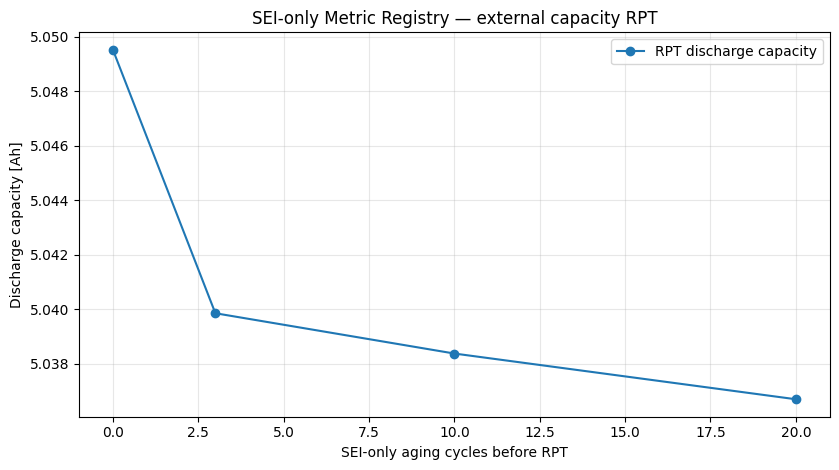

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_metric_registry_capacity_rpt_drift.png


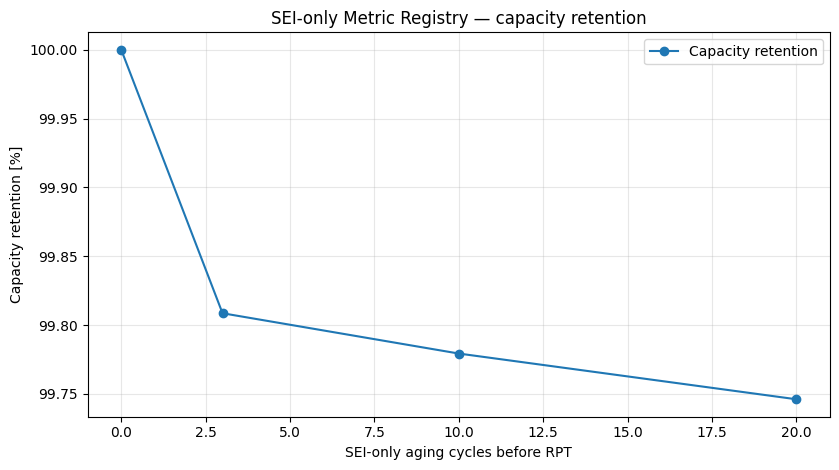

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_metric_registry_capacity_retention.png


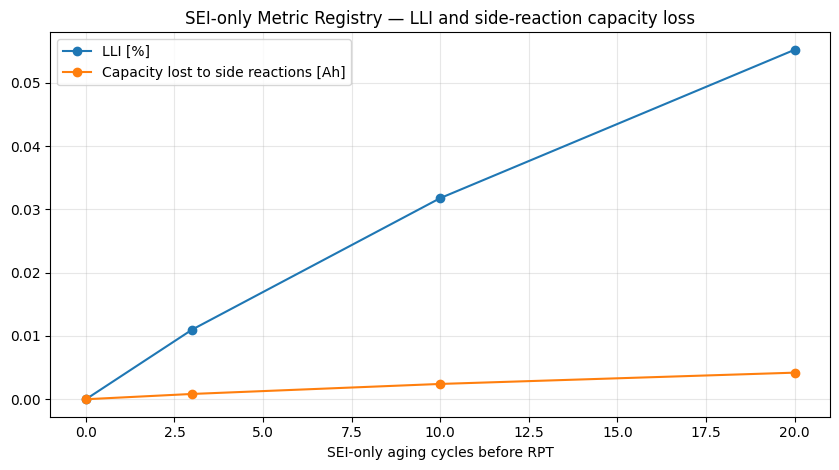

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_metric_registry_LLI_capacity_loss.png


In [23]:
# Cell 14 — Plot capacity and degradation-state drift（绘制容量与老化状态漂移）

plot_df = metric_registry_drift_table.sort_values("checkpoint_cycles").copy()

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["rpt_discharge_capacity_Ah"],
    marker="o",
    label="RPT discharge capacity",
)

ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_ylabel("Discharge capacity [Ah]")
ax.set_title("SEI-only Metric Registry — external capacity RPT")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_metric_registry_capacity_rpt_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["capacity_retention_pct"],
    marker="o",
    label="Capacity retention",
)

ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_ylabel("Capacity retention [%]")
ax.set_title("SEI-only Metric Registry — capacity retention")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_metric_registry_capacity_retention.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["loss_lithium_inventory_pct"],
    marker="o",
    label="LLI [%]",
)

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["capacity_lost_side_reactions_Ah"],
    marker="o",
    label="Capacity lost to side reactions [Ah]",
)

ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_title("SEI-only Metric Registry — LLI and side-reaction capacity loss")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_metric_registry_LLI_capacity_loss.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

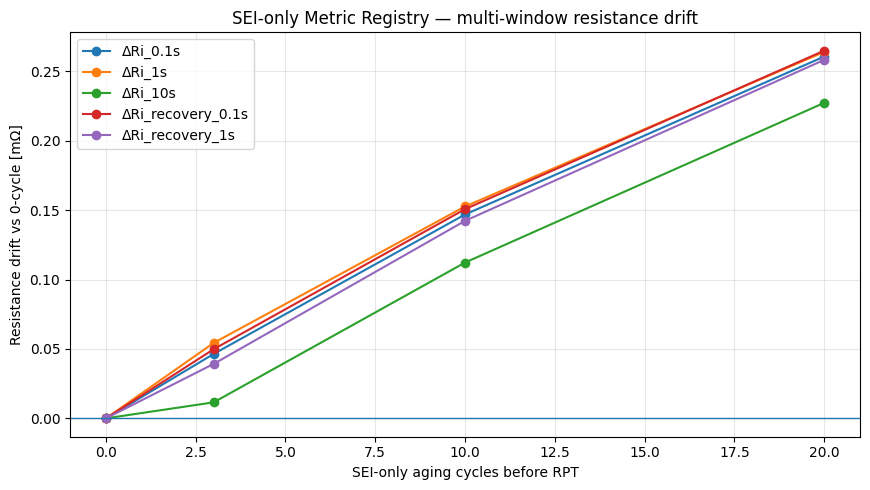

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_metric_registry_multi_window_Ri_drift.png


In [24]:
# Cell 15 — Plot multi-window Ri drift（绘制多时间窗 Ri 漂移）

plot_df = metric_registry_drift_table.sort_values("checkpoint_cycles").copy()

fig, ax = plt.subplots(figsize=(8.8, 5))

ri_delta_metrics = [
    ("Ri_0p1s_mohm_delta_vs_0cycle", "ΔRi_0.1s"),
    ("Ri_1s_mohm_delta_vs_0cycle", "ΔRi_1s"),
    ("Ri_10s_mohm_delta_vs_0cycle", "ΔRi_10s"),
    ("Ri_recovery_0p1s_mohm_delta_vs_0cycle", "ΔRi_recovery_0.1s"),
    ("Ri_recovery_1s_mohm_delta_vs_0cycle", "ΔRi_recovery_1s"),
]

for col, label in ri_delta_metrics:
    ax.plot(
        plot_df["checkpoint_cycles"],
        plot_df[col],
        marker="o",
        label=label,
    )

ax.axhline(0, linewidth=1)
ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_ylabel("Resistance drift vs 0-cycle [mΩ]")
ax.set_title("SEI-only Metric Registry — multi-window resistance drift")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_metric_registry_multi_window_Ri_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

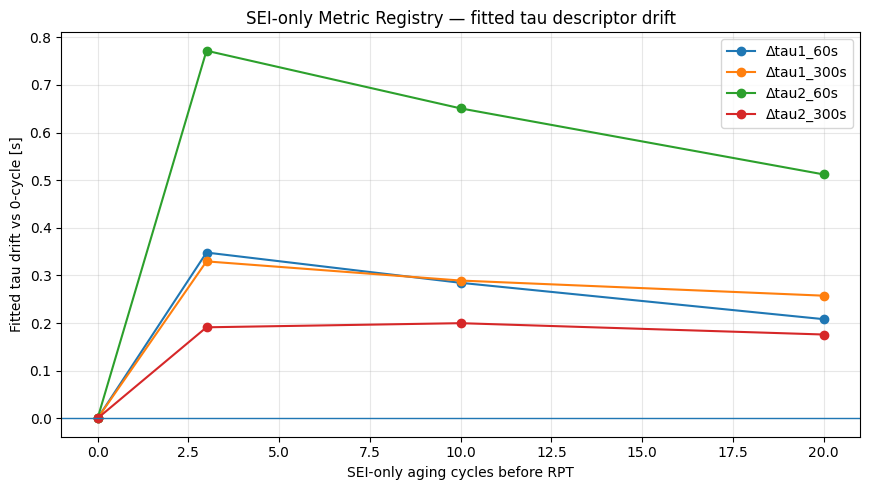

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_metric_registry_fitted_tau_drift.png


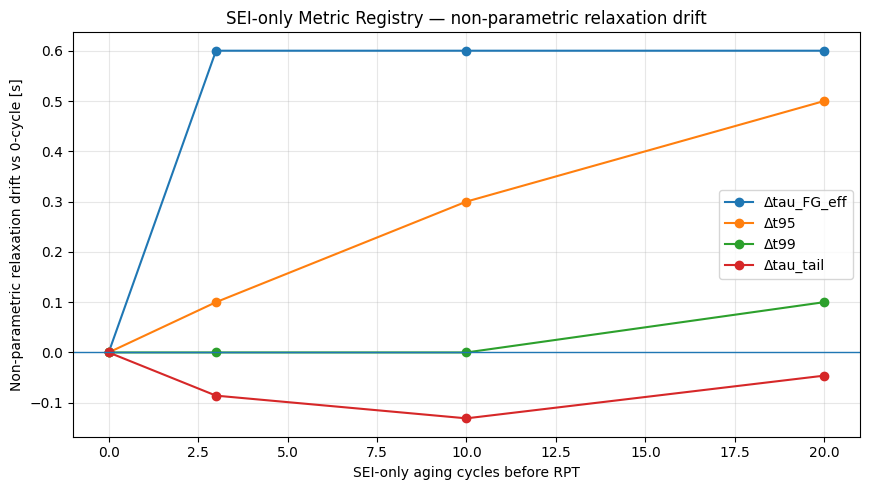

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_metric_registry_nonparam_relaxation_drift.png


In [25]:
# Cell 16 — Plot relaxation descriptor drift（绘制拟合与非参数 relaxation 指标漂移）

plot_df = metric_registry_drift_table.sort_values("checkpoint_cycles").copy()

fig, ax = plt.subplots(figsize=(8.8, 5))

tau_delta_metrics = [
    ("tau1_60s_delta_vs_0cycle", "Δtau1_60s"),
    ("tau1_300s_delta_vs_0cycle", "Δtau1_300s"),
    ("tau2_60s_delta_vs_0cycle", "Δtau2_60s"),
    ("tau2_300s_delta_vs_0cycle", "Δtau2_300s"),
]

for col, label in tau_delta_metrics:
    ax.plot(
        plot_df["checkpoint_cycles"],
        plot_df[col],
        marker="o",
        label=label,
    )

ax.axhline(0, linewidth=1)
ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_ylabel("Fitted tau drift vs 0-cycle [s]")
ax.set_title("SEI-only Metric Registry — fitted tau descriptor drift")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_metric_registry_fitted_tau_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


fig, ax = plt.subplots(figsize=(8.8, 5))

nonparam_delta_metrics = [
    ("tau_FG_eff_s_delta_vs_0cycle", "Δtau_FG_eff"),
    ("t95_s_delta_vs_0cycle", "Δt95"),
    ("t99_s_delta_vs_0cycle", "Δt99"),
    ("tau_tail_s_delta_vs_0cycle", "Δtau_tail"),
]

for col, label in nonparam_delta_metrics:
    ax.plot(
        plot_df["checkpoint_cycles"],
        plot_df[col],
        marker="o",
        label=label,
    )

ax.axhline(0, linewidth=1)
ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_ylabel("Non-parametric relaxation drift vs 0-cycle [s]")
ax.set_title("SEI-only Metric Registry — non-parametric relaxation drift")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_metric_registry_nonparam_relaxation_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

## Non-parametric relaxation descriptor definitions

The non-parametric relaxation descriptors are extracted from the voltage recovery segment after the 1C 10 s HPPC discharge pulse.

Let:

- `U0` be the first voltage point after current interruption.
- `Uinf` be the median voltage over the final 50 s of the 600 s relaxation window.
- `A = Uinf - U0` be the recovery amplitude.

The normalized recovery fraction is defined as:

`recovery_fraction(t) = (U(t) - U0) / (Uinf - U0)`

The normalized remaining polarization is defined as:

`remaining_fraction(t) = (Uinf - U(t)) / (Uinf - U0)`

The descriptors are:

- `tau_FG_eff`: first time at which recovery_fraction reaches 63.2%.
- `t95`: first time at which recovery_fraction reaches 95%.
- `t99`: first time at which recovery_fraction reaches 99%.
- `tau_tail`: effective time constant obtained from the late semilog slope of remaining_fraction between 300 s and 550 s.
- `recovery_area`: trapezoidal integral of remaining_fraction over the relaxation window.

These descriptors are non-parametric or weakly parametric recovery-shape indicators. They are not identical to the fitted `tau1` / `tau2` values from the bi-exponential model.

In [26]:
# Cell 16A — Non-parametric relaxation metric definition table
# 功能：显式记录 tau_FG_eff / t95 / t99 / tau_tail / recovery_area 的定义

relaxation_metric_definition_rows = [
    {
        "metric": "relax_U0_V",
        "definition": "First voltage point after HPPC pulse current interruption",
        "unit": "V",
        "source_segment": "post-pulse relaxation",
        "interpretation": "initial recovery voltage after load removal",
    },
    {
        "metric": "relax_Uinf_V",
        "definition": "Median voltage over the final 50 s of the 600 s relaxation window",
        "unit": "V",
        "source_segment": "late relaxation tail",
        "interpretation": "finite-window approximation of relaxed voltage",
    },
    {
        "metric": "recovery_amplitude_V",
        "definition": "relax_Uinf_V - relax_U0_V",
        "unit": "V",
        "source_segment": "post-pulse relaxation",
        "interpretation": "voltage recovery amplitude after pulse interruption",
    },
    {
        "metric": "recovery_fraction",
        "definition": "(U(t) - U0) / (Uinf - U0)",
        "unit": "-",
        "source_segment": "post-pulse relaxation",
        "interpretation": "normalized voltage recovery progress",
    },
    {
        "metric": "remaining_fraction",
        "definition": "(Uinf - U(t)) / (Uinf - U0)",
        "unit": "-",
        "source_segment": "post-pulse relaxation",
        "interpretation": "normalized remaining polarization",
    },
    {
        "metric": "tau_FG_eff_s",
        "definition": "First time after pulse end when recovery_fraction reaches 1 - exp(-1), approximately 63.2%",
        "unit": "s",
        "source_segment": "post-pulse relaxation",
        "interpretation": "non-parametric effective recovery time constant",
    },
    {
        "metric": "t95_s",
        "definition": "First time after pulse end when recovery_fraction reaches 0.95",
        "unit": "s",
        "source_segment": "post-pulse relaxation",
        "interpretation": "time required to reach 95% voltage recovery",
    },
    {
        "metric": "t99_s",
        "definition": "First time after pulse end when recovery_fraction reaches 0.99",
        "unit": "s",
        "source_segment": "post-pulse relaxation",
        "interpretation": "time required to reach 99% voltage recovery",
    },
    {
        "metric": "tau_tail_s",
        "definition": "Effective time constant from semilog slope of remaining_fraction between 300 s and 550 s",
        "unit": "s",
        "source_segment": "late relaxation tail",
        "interpretation": "late-tail relaxation descriptor",
    },
    {
        "metric": "recovery_area_s",
        "definition": "Trapezoidal integral of remaining_fraction over the valid relaxation window",
        "unit": "s",
        "source_segment": "post-pulse relaxation",
        "interpretation": "integrated remaining polarization over time",
    },
]

relaxation_metric_definition_table = pd.DataFrame(relaxation_metric_definition_rows)

out_csv = DATA / "nonparametric_relaxation_metric_definitions.csv"
relaxation_metric_definition_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(relaxation_metric_definition_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/nonparametric_relaxation_metric_definitions.csv


,metric,definition,unit,source_segment,interpretation
0,relax_U0_V,First voltage point after HPPC pulse current i...,V,post-pulse relaxation,initial recovery voltage after load removal
1,relax_Uinf_V,Median voltage over the final 50 s of the 600 ...,V,late relaxation tail,finite-window approximation of relaxed voltage
2,recovery_amplitude_V,relax_Uinf_V - relax_U0_V,V,post-pulse relaxation,voltage recovery amplitude after pulse interru...
3,recovery_fraction,(U(t) - U0) / (Uinf - U0),-,post-pulse relaxation,normalized voltage recovery progress
4,remaining_fraction,(Uinf - U(t)) / (Uinf - U0),-,post-pulse relaxation,normalized remaining polarization
5,tau_FG_eff_s,First time after pulse end when recovery_fract...,s,post-pulse relaxation,non-parametric effective recovery time constant
6,t95_s,First time after pulse end when recovery_fract...,s,post-pulse relaxation,time required to reach 95% voltage recovery
7,t99_s,First time after pulse end when recovery_fract...,s,post-pulse relaxation,time required to reach 99% voltage recovery
8,tau_tail_s,Effective time constant from semilog slope of ...,s,late relaxation tail,late-tail relaxation descriptor
9,recovery_area_s,Trapezoidal integral of remaining_fraction ove...,s,post-pulse relaxation,integrated remaining polarization over time


In [27]:
# Cell 16B — Non-parametric relaxation metric caveat table
# 功能：记录非参数 relaxation 指标的解释边界

relaxation_metric_caveat_rows = [
    {
        "metric": "tau_FG_eff_s",
        "main_caveat": "quantized by sampling period and threshold crossing",
        "interpretation_boundary": "small changes below the sampling resolution should not be over-interpreted",
    },
    {
        "metric": "t95_s",
        "main_caveat": "sensitive to Uinf definition and late-window voltage drift",
        "interpretation_boundary": "compare only under identical relaxation-window definitions",
    },
    {
        "metric": "t99_s",
        "main_caveat": "very sensitive to tail noise and Uinf estimate",
        "interpretation_boundary": "best used as audit descriptor, not sole mechanistic evidence",
    },
    {
        "metric": "tau_tail_s",
        "main_caveat": "depends on chosen semilog fitting window",
        "interpretation_boundary": "valid only for the selected 300–550 s tail window",
    },
    {
        "metric": "recovery_area_s",
        "main_caveat": "depends on normalization by recovery amplitude",
        "interpretation_boundary": "unstable if recovery amplitude is extremely small",
    },
]

relaxation_metric_caveat_table = pd.DataFrame(relaxation_metric_caveat_rows)

out_csv = DATA / "nonparametric_relaxation_metric_caveats.csv"
relaxation_metric_caveat_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(relaxation_metric_caveat_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/nonparametric_relaxation_metric_caveats.csv


,metric,main_caveat,interpretation_boundary
0,tau_FG_eff_s,quantized by sampling period and threshold cro...,small changes below the sampling resolution sh...
1,t95_s,sensitive to Uinf definition and late-window v...,compare only under identical relaxation-window...
2,t99_s,very sensitive to tail noise and Uinf estimate,"best used as audit descriptor, not sole mechan..."
3,tau_tail_s,depends on chosen semilog fitting window,valid only for the selected 300–550 s tail window
4,recovery_area_s,depends on normalization by recovery amplitude,unstable if recovery amplitude is extremely small


In [28]:
# Cell 17 — Voltage-recovery / pseudo-OCV feasibility audit
# 功能：记录当前 notebook 中可支持的 voltage-recovery / pseudo-OCV 指标及其边界

voltage_feature_rows = []

plot_df = metric_registry_drift_table.sort_values("checkpoint_cycles").copy()

for _, row in plot_df.iterrows():
    voltage_feature_rows.append(
        {
            "checkpoint_cycles": row["checkpoint_cycles"],
            "feature_family": "HPPC_post_pulse_voltage_recovery",
            "U00_after_600s_rest_proxy_V": row["relax_Uinf_V"],
            "U00_after_600s_rest_proxy_delta_vs_0cycle_V": row["relax_Uinf_V_delta_vs_0cycle"],
            "initial_recovery_voltage_U0_V": row["relax_U0_V"],
            "recovery_amplitude_V": row["recovery_amplitude_V"],
            "recovery_amplitude_delta_vs_0cycle_V": row["recovery_amplitude_V_delta_vs_0cycle"],
            "status": "feasibility",
            "interpretation_boundary": (
                "This is a finite-rest post-pulse voltage recovery descriptor, "
                "not a strict OCV-SOC curve."
            ),
        }
    )

voltage_recovery_feasibility_table = pd.DataFrame(voltage_feature_rows)

out_csv = DATA / "sei_metric_registry_voltage_recovery_feasibility_table.csv"
voltage_recovery_feasibility_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(voltage_recovery_feasibility_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_metric_registry_voltage_recovery_feasibility_table.csv


,checkpoint_cycles,feature_family,U00_after_600s_rest_proxy_V,U00_after_600s_rest_proxy_delta_vs_0cycle_V,initial_recovery_voltage_U0_V,recovery_amplitude_V,recovery_amplitude_delta_vs_0cycle_V,status,interpretation_boundary
0,0,HPPC_post_pulse_voltage_recovery,3.755718,0.000000,3.710716,0.045002,0.000000,feasibility,This is a finite-rest post-pulse voltage recov...
1,3,HPPC_post_pulse_voltage_recovery,3.753931,-0.001787,3.709226,0.044705,-0.000297,feasibility,This is a finite-rest post-pulse voltage recov...
2,10,HPPC_post_pulse_voltage_recovery,3.753949,-0.001769,3.709222,0.044726,-0.000276,feasibility,This is a finite-rest post-pulse voltage recov...
3,20,HPPC_post_pulse_voltage_recovery,3.753974,-0.001744,3.709218,0.044756,-0.000246,feasibility,This is a finite-rest post-pulse voltage recov...


In [29]:
# Cell 18 — Deferred metric registry table
# 功能：记录当前尚不能解释或需要独立协议的指标层

deferred_metric_rows = [
    {
        "layer": "voltage_curve_OCV",
        "metric": "strict_OCV_SOC_curve",
        "status": "deferred",
        "reason": "requires low-rate or quasi-equilibrium OCV protocol",
        "future_protocol": "C/20 or C/25 full charge/discharge, or GITT-like pulse-rest sequence",
        "current_notebook_boundary": "not available from HPPC pulse alone",
    },
    {
        "layer": "ICA_DVA",
        "metric": "dQ/dV and dV/dQ peak features",
        "status": "deferred",
        "reason": "requires smooth low-rate voltage-capacity curve and preprocessing",
        "future_protocol": "low-rate full-window charge/discharge curve with smoothing and derivative extraction",
        "current_notebook_boundary": "not computed in Notebook 15",
    },
    {
        "layer": "fixed_endpoint_pseudo_OCV",
        "metric": "U00_after_fixed_Ukl_and_fixed_rest",
        "status": "deferred",
        "reason": "requires dedicated fixed-voltage-endpoint protocol",
        "future_protocol": "fixed C-rate to same Ukl, current interruption, fixed rest, record U00",
        "current_notebook_boundary": "current HPPC rest voltage is not same-Ukl endpoint test",
    },
    {
        "layer": "thermal",
        "metric": "heat generation / temperature rise / irreversible heat",
        "status": "deferred_until_non_isothermal_branch",
        "reason": "current model configuration is isothermal",
        "future_protocol": "activate thermal model and heat-source variables",
        "current_notebook_boundary": "not interpretable under current isothermal branch",
    },
]

deferred_metric_registry_table = pd.DataFrame(deferred_metric_rows)

out_csv = DATA / "sei_metric_registry_deferred_metrics_table.csv"
deferred_metric_registry_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(deferred_metric_registry_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_metric_registry_deferred_metrics_table.csv


,layer,metric,status,reason,future_protocol,current_notebook_boundary
0,voltage_curve_OCV,strict_OCV_SOC_curve,deferred,requires low-rate or quasi-equilibrium OCV pro...,"C/20 or C/25 full charge/discharge, or GITT-li...",not available from HPPC pulse alone
1,ICA_DVA,dQ/dV and dV/dQ peak features,deferred,requires smooth low-rate voltage-capacity curv...,low-rate full-window charge/discharge curve wi...,not computed in Notebook 15
2,fixed_endpoint_pseudo_OCV,U00_after_fixed_Ukl_and_fixed_rest,deferred,requires dedicated fixed-voltage-endpoint prot...,"fixed C-rate to same Ukl, current interruption...",current HPPC rest voltage is not same-Ukl endp...
3,thermal,heat generation / temperature rise / irreversi...,deferred_until_non_isothermal_branch,current model configuration is isothermal,activate thermal model and heat-source variables,not interpretable under current isothermal branch


In [30]:
# Cell 19 — Metric Registry v0.1 final classification table
# 功能：基于扩展指标体系，对 SEI-only fingerprint 进行最终分类

final_row = metric_registry_drift_table.sort_values("checkpoint_cycles").iloc[-1]

classification_rows = [
    {
        "metric_layer": "degradation_state",
        "main_metrics": "SEI thickness, LLI, total lithium lost, side-reaction capacity loss",
        "final_evidence": (
            f"SEI thickness Δ = {final_row['sei_thickness_m_delta_vs_0cycle']:.3e} m; "
            f"LLI = {final_row['loss_lithium_inventory_pct']:.5f} %; "
            f"side-reaction capacity loss = {final_row['capacity_lost_side_reactions_Ah']:.6f} Ah"
        ),
        "strength": "strong",
        "classification": "primary SEI-only degradation-state signature",
    },
    {
        "metric_layer": "external_capacity_RPT",
        "main_metrics": "RPT discharge capacity, capacity retention, capacity fade",
        "final_evidence": (
            f"capacity retention = {final_row['capacity_retention_pct']:.4f} %; "
            f"capacity fade = {final_row['capacity_fade_pct']:.4f} %; "
            f"capacity loss = {final_row['capacity_loss_Ah_vs_0cycle']:.6f} Ah"
        ),
        "strength": "clear but small",
        "classification": "external capacity signature consistent with LLI / side reaction loss",
    },
    {
        "metric_layer": "multi_window_Ri",
        "main_metrics": "Ri_0.1s, Ri_1s, Ri_10s, recovery Ri",
        "final_evidence": (
            f"ΔRi_0.1s = {final_row['Ri_0p1s_mohm_delta_vs_0cycle']:.4f} mΩ; "
            f"ΔRi_1s = {final_row['Ri_1s_mohm_delta_vs_0cycle']:.4f} mΩ; "
            f"ΔRi_10s = {final_row['Ri_10s_mohm_delta_vs_0cycle']:.4f} mΩ"
        ),
        "strength": "weak but monotonic",
        "classification": "secondary Ri-sensitive component",
    },
    {
        "metric_layer": "fitted_tau",
        "main_metrics": "tau1_60s, tau1_300s, tau2_60s, tau2_300s",
        "final_evidence": (
            f"Δtau1_60s = {final_row['tau1_60s_delta_vs_0cycle']:.4f} s; "
            f"Δtau1_300s = {final_row['tau1_300s_delta_vs_0cycle']:.4f} s; "
            f"Δtau2_60s = {final_row['tau2_60s_delta_vs_0cycle']:.4f} s; "
            f"Δtau2_300s = {final_row['tau2_300s_delta_vs_0cycle']:.4f} s"
        ),
        "strength": "weak / non-dominant",
        "classification": "not dominant SEI-only fingerprint",
    },
    {
        "metric_layer": "nonparametric_relaxation",
        "main_metrics": "tau_FG_eff, t95, t99, tau_tail, recovery area",
        "final_evidence": (
            f"Δtau_FG_eff = {final_row['tau_FG_eff_s_delta_vs_0cycle']:.4f} s; "
            f"Δt95 = {final_row['t95_s_delta_vs_0cycle']:.4f} s; "
            f"Δt99 = {final_row['t99_s_delta_vs_0cycle']:.4f} s; "
            f"Δtau_tail = {final_row['tau_tail_s_delta_vs_0cycle']:.4f} s"
        ),
        "strength": "weak / secondary audit layer",
        "classification": "useful as recovery-shape audit, not primary fingerprint",
    },
    {
        "metric_layer": "voltage_recovery_pseudo_OCV",
        "main_metrics": "relax_Uinf, recovery amplitude",
        "final_evidence": (
            f"Δrelax_Uinf = {final_row['relax_Uinf_V_delta_vs_0cycle']:.6f} V; "
            f"Δrecovery_amplitude = {final_row['recovery_amplitude_V_delta_vs_0cycle']:.6f} V"
        ),
        "strength": "feasibility-level",
        "classification": "finite-rest recovery voltage feature; not strict OCV",
    },
    {
        "metric_layer": "overall",
        "main_metrics": "all active layers",
        "final_evidence": (
            "Strong degradation-state drift, clear external capacity fade, "
            "weak monotonic multi-window Ri drift, and weak relaxation-descriptor drift"
        ),
        "strength": "mixed but capacity/LLI-dominant",
        "classification": (
            "SEI-only aging primarily projects into capacity / LLI degradation-state "
            "and external capacity metrics, with a weak Ri component."
        ),
    },
]

sei_metric_registry_classification_table = pd.DataFrame(classification_rows)

out_csv = DATA / "sei_metric_registry_v0_1_classification_table.csv"
sei_metric_registry_classification_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(sei_metric_registry_classification_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_metric_registry_v0_1_classification_table.csv


,metric_layer,main_metrics,final_evidence,strength,classification
0,degradation_state,"SEI thickness, LLI, total lithium lost, side-r...",SEI thickness Δ = 4.472e-09 m; LLI = 0.05520 %...,strong,primary SEI-only degradation-state signature
1,external_capacity_RPT,"RPT discharge capacity, capacity retention, ca...",capacity retention = 99.7461 %; capacity fade ...,clear but small,external capacity signature consistent with LL...
2,multi_window_Ri,"Ri_0.1s, Ri_1s, Ri_10s, recovery Ri",ΔRi_0.1s = 0.2606 mΩ; ΔRi_1s = 0.2639 mΩ; ΔRi_...,weak but monotonic,secondary Ri-sensitive component
3,fitted_tau,"tau1_60s, tau1_300s, tau2_60s, tau2_300s",Δtau1_60s = 0.2082 s; Δtau1_300s = 0.2575 s; Δ...,weak / non-dominant,not dominant SEI-only fingerprint
4,nonparametric_relaxation,"tau_FG_eff, t95, t99, tau_tail, recovery area",Δtau_FG_eff = 0.6000 s; Δt95 = 0.5000 s; Δt99 ...,weak / secondary audit layer,"useful as recovery-shape audit, not primary fi..."
5,voltage_recovery_pseudo_OCV,"relax_Uinf, recovery amplitude",Δrelax_Uinf = -0.001744 V; Δrecovery_amplitude...,feasibility-level,finite-rest recovery voltage feature; not stri...
6,overall,all active layers,"Strong degradation-state drift, clear external...",mixed but capacity/LLI-dominant,SEI-only aging primarily projects into capacit...


In [31]:
# Cell 20 — Metric Registry coverage table
# 功能：记录 Metric Registry v0.1 中各层指标在 Notebook 15 的覆盖状态

coverage_rows = [
    {
        "layer": "degradation_state",
        "coverage": "implemented",
        "key_outputs": "SEI thickness, LLI, lithium lost, side-reaction capacity loss",
        "status": "active",
    },
    {
        "layer": "external_capacity_RPT",
        "coverage": "implemented",
        "key_outputs": "RPT discharge capacity, retention, fade",
        "status": "active",
    },
    {
        "layer": "multi_window_Ri",
        "coverage": "implemented",
        "key_outputs": "Ri_0.1s, Ri_1s, Ri_10s, recovery Ri",
        "status": "active",
    },
    {
        "layer": "fitted_relaxation",
        "coverage": "implemented",
        "key_outputs": "tau1/tau2 at 60s and 300s windows",
        "status": "active",
    },
    {
        "layer": "nonparametric_relaxation",
        "coverage": "implemented",
        "key_outputs": "tau_FG_eff, t95, t99, tau_tail, recovery area",
        "status": "active",
    },
    {
        "layer": "voltage_recovery_pseudo_OCV",
        "coverage": "partially implemented",
        "key_outputs": "HPPC finite-rest Uinf and recovery amplitude",
        "status": "feasibility",
    },
    {
        "layer": "voltage_curve_OCV_ICA_DVA",
        "coverage": "not implemented",
        "key_outputs": "requires low-rate / quasi-OCV protocol",
        "status": "deferred",
    },
    {
        "layer": "thermal",
        "coverage": "not implemented",
        "key_outputs": "requires non-isothermal model",
        "status": "deferred",
    },
]

metric_registry_coverage_table = pd.DataFrame(coverage_rows)

out_csv = DATA / "metric_registry_v0_1_coverage_table.csv"
metric_registry_coverage_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(metric_registry_coverage_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/metric_registry_v0_1_coverage_table.csv


,layer,coverage,key_outputs,status
0,degradation_state,implemented,"SEI thickness, LLI, lithium lost, side-reactio...",active
1,external_capacity_RPT,implemented,"RPT discharge capacity, retention, fade",active
2,multi_window_Ri,implemented,"Ri_0.1s, Ri_1s, Ri_10s, recovery Ri",active
3,fitted_relaxation,implemented,tau1/tau2 at 60s and 300s windows,active
4,nonparametric_relaxation,implemented,"tau_FG_eff, t95, t99, tau_tail, recovery area",active
5,voltage_recovery_pseudo_OCV,partially implemented,HPPC finite-rest Uinf and recovery amplitude,feasibility
6,voltage_curve_OCV_ICA_DVA,not implemented,requires low-rate / quasi-OCV protocol,deferred
7,thermal,not implemented,requires non-isothermal model,deferred


# Notebook 15 Conclusion

This notebook extended the SEI-only aging fingerprint study by implementing Metric Registry v0.1.

The purpose was to move beyond the initial Ri / tau1 / tau2 audit and include additional externally observable diagnostic layers.

## Key outputs

This notebook generated:

- `data/metric_registry_v0_1.csv`
- `data/sei_metric_registry_preconditioned_degradation_state_table.csv`
- `data/sei_metric_registry_preconditioned_capacity_rpt_table.csv`
- `data/sei_metric_registry_preconditioned_hppc_rpt_table.csv`
- `data/sei_metric_registry_preconditioned_drift_table.csv`
- `data/nonparametric_relaxation_metric_definitions.csv`
- `data/nonparametric_relaxation_metric_caveats.csv`
- `data/sei_metric_registry_voltage_recovery_feasibility_table.csv`
- `data/sei_metric_registry_deferred_metrics_table.csv`
- `data/sei_metric_registry_v0_1_classification_table.csv`
- `data/metric_registry_v0_1_coverage_table.csv`

## Key findings

### 1. Metric Registry v0.1 was established

The following diagnostic layers were implemented or registered:

- degradation-state variables,
- external capacity RPT metrics,
- multi-window resistance metrics,
- fitted tau1 / tau2 descriptors,
- non-parametric relaxation descriptors,
- voltage-recovery / pseudo-OCV feasibility metrics,
- deferred OCV / ICA / DVA features,
- deferred thermal metrics.

This provides a structured aging fingerprint framework rather than relying on a single observable.

### 2. Capacity RPT required preconditioning

The initial capacity RPT comparison showed a start-voltage mismatch of approximately 64 mV.

Therefore, a full-charge diagnostic preconditioning step was introduced:

- charge at C/3 until 4.2 V,
- hold at 4.2 V until C/100,
- rest for 10 minutes.

After preconditioning, the capacity RPT start-voltage spread was reduced to approximately 4.4 mV.

The preconditioned capacity RPT outputs were therefore used for the final metric registry analysis.

### 3. External capacity RPT confirms a capacity-loss signature

The external capacity RPT showed decreasing discharge capacity with SEI-only aging.

At the final 20-cycle checkpoint:

- capacity retention was approximately `99.7461 %`,
- capacity fade was approximately `0.2539 %`,
- capacity loss relative to the 0-cycle RPT was approximately `0.01282 Ah`.

This external capacity signature is consistent with the internal LLI and side-reaction capacity-loss variables.

### 4. Degradation-state variables remain the strongest SEI-only signature

The internal degradation-state variables showed clear growth:

- SEI thickness increased,
- loss of lithium inventory increased,
- total lithium lost increased,
- capacity lost to side reactions increased.

At the final checkpoint:

- SEI thickness increased by approximately `4.47e-9 m`,
- LLI reached approximately `0.0552 %`,
- side-reaction capacity loss reached approximately `0.00420 Ah`.

This confirms that the strongest SEI-only signature is still the capacity / LLI degradation-state layer.

### 5. Multi-window Ri shows weak but monotonic drift

The multi-window resistance metrics show a consistent weak increase.

At the final checkpoint:

- `Ri_0.1s` increased by approximately `0.2606 mΩ`,
- `Ri_1s` increased by approximately `0.2639 mΩ`,
- `Ri_10s` increased by approximately `0.2272 mΩ`.

This supports a secondary Ri-sensitive component, but the magnitude remains weak compared with the degradation-state and capacity layers.

### 6. Fitted tau1/tau2 descriptors are not dominant

The fitted relaxation descriptors were audited for both fast and slow components.

At the final checkpoint:

- `tau1_60s` drift was approximately `0.2082 s`,
- `tau1_300s` drift was approximately `0.2575 s`,
- `tau2_60s` drift was approximately `0.5120 s`,
- `tau2_300s` drift was approximately `0.1727 s`.

These values are small relative to the main degradation-state and capacity signatures.

Therefore, fitted tau1 / tau2 descriptors are secondary audit metrics, not the dominant SEI-only aging fingerprint.

### 7. Non-parametric relaxation descriptors were defined and audited

The notebook explicitly defined:

- `tau_FG_eff`,
- `t95`,
- `t99`,
- `tau_tail`,
- `recovery_amplitude`,
- `recovery_area`.

These descriptors were successfully extracted.

At the final checkpoint:

- `tau_FG_eff` drift was approximately `0.6 s`,
- `t95` drift was approximately `0.5 s`,
- `t99` drift was approximately `0.1 s`,
- `tau_tail` drift remained small.

These descriptors are useful as recovery-shape audit metrics, but they do not form the primary SEI-only fingerprint in the present protocol.

### 8. Voltage-recovery / pseudo-OCV layer is feasibility-level only

The notebook extracted finite-rest voltage recovery descriptors from the HPPC relaxation segment, including:

- finite-window `Uinf`,
- recovery amplitude,
- voltage recovery drift.

These are useful voltage-recovery fingerprints.

However, they are not strict OCV-SOC measurements.

The current HPPC rest voltage should be interpreted as a finite-rest recovery descriptor, not as a true OCV curve.

### 9. OCV / ICA / DVA and thermal metrics are deferred

The following layers were registered but not interpreted:

- strict OCV-SOC curve,
- ICA / DVA features,
- fixed-endpoint pseudo-OCV after same Ukl,
- thermal / heat-generation indicators.

These require dedicated protocols or model branches.

In particular:

- OCV / ICA / DVA require low-rate or quasi-equilibrium voltage curves.
- fixed-endpoint pseudo-OCV requires a same-Ukl + fixed-rest protocol.
- thermal indicators require a non-isothermal model branch.

## Overall classification

Using Metric Registry v0.1, the SEI-only fingerprint is classified as:

`capacity / LLI dominant mixed signature`

with:

- strong degradation-state drift,
- clear but small external capacity fade,
- weak but monotonic multi-window Ri drift,
- weak fitted tau1 / tau2 drift,
- weak non-parametric relaxation drift,
- feasibility-level voltage-recovery features.

The dominant observable layer is the capacity / LLI layer.

The Ri layer is secondary.

The relaxation layer is useful for audit but not dominant.

## Interpretation boundary

This notebook does not establish a validated SEI aging law or real-cell SOH trajectory.

The current cycling and RPT protocols are proof-of-concept simulation protocols.

The capacity RPT and HPPC/RPT branches are diagnostic only and are not used as the starting point for subsequent aging.

The RPT conditioning is nominal-capacity based and approximate.

Voltage-recovery metrics are finite-rest descriptors, not strict OCV measurements.

Thermal metrics are not interpretable under the current isothermal configuration.

## Next step

The next step should be a consolidation update:

- update README,
- update `docs/project_summary.md`,
- copy representative SEI Metric Registry figures into `docs/figures`,
- copy representative Metric Registry tables into `docs/tables`.

After documentation consolidation, the next technical branch can be either:

- a dedicated OCV / ICA / DVA feasibility notebook,
- a fixed-endpoint pseudo-OCV protocol notebook,
- a non-isothermal thermal audit branch,
- or a plating-stress entry audit.